# Apply an evolved proofreader policy to the TEST brain & compare before/after

Takes the **final accepted policy** from a `proofreader_evolve` run and runs it on the
run's **TEST (held-out) brain** — the honest generalization signal, since the policy was
never trained on these skeletons. For the cross-brain run
`794491_train1_test1_20260714_011120` that is **brain 794495** (19 held-out GT
skeletons); the reviser only ever saw 794491 (train).

1. **Metric comparison** — baseline (no edits) vs edited, per skeleton: split-repair score, `# Splits`, `% Merged Edges`, Edge Accuracy, `# Merges`.
2. **Volume visualization** — pick one SplitSite the policy *repaired*, and render its local receptive field (raw image + fragment skeletons) coloured by **baseline labels vs edited (merged) labels**, side by side, so the repair is visible in 3D context (mirrors `visualization_showcase.ipynb`).

The policy is `propose_edits` from the run's `gen<NN>/heuristics.accepted.py`; it reasons over GT-free fragment geometry only, so it is deployable. Scoring uses the same incremental scorer the evolution loop uses (verified equal to `segmentation_skeleton_metrics.evaluate`), with the SAME `--max-class-size` cap the run used.

> Sections 1-8b cover the **TEST** brain in depth; **Section 10** adds the **TRAIN** brain (repaired splits + merge errors, via the shared `plotting/policy_viz.py`), so both brains are rendered — each exactly once.

## 0. Setup — env, paths, parameters

In [1]:
import os
import sys
import json
import re
import shlex
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Same env / path setup as notebooks/load_skeletons_from_cache.ipynb.
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../../configs/zihan_gcs_token.json"
os.environ["AWS_EC2_METADATA_DISABLED"] = "true"

# Make proofreader_evolve and the metrics package importable.
PROJ = Path("../..").resolve()                      # exa-spim-agent/
sys.path.insert(0, str(PROJ))
sys.path.insert(0, str(PROJ.parent / "segmentation-skeleton-metrics" / "src"))

from proofreader_evolve.harness import incremental_scoring as inc
from proofreader_evolve.harness import dataset as ds
from proofreader_evolve.harness import candidate as cand
from proofreader_evolve.harness import scoring
from proofreader_evolve.harness.edit_handler import normalize_edits
from agentic_neuron_proofreader.utils import img_util

# --- Parameters -----------------------------------------------------------
RUN_NAME = "794495_train1_test1_20260715_005246"   # the evolution run to take the policy from
GEN = None                                     # None -> auto = the LAST accepted generation
                                               # (best policy); or set e.g. "gen24" to pin one.
# BRAIN_ID: which brain to act the policy on. None -> auto = the run's TEST/held-out
# brain (cross-brain runs record it in split.json under "test_brains"). This is the
# generalization brain the reviser never trained on.
BRAIN_ID = None

RUNS = PROJ / "proofreader_evolve" / "runs"
RUN_DIR = RUNS / RUN_NAME

_split_cfg = json.loads((RUN_DIR / "split.json").read_text())

# Auto-resolve BRAIN_ID to the run's TEST brain (cross-brain) — the held-out
# generalization brain. For a legacy per-brain-split run (no test_brains) fall back to
# the single brain the run used.
if BRAIN_ID is None:
    _test = _split_cfg.get("test_brains") or []
    if _test:
        BRAIN_ID = str(_test[0])
        print(f"BRAIN_ID auto-resolved to the run's TEST (held-out) brain: {BRAIN_ID} "
              f"(train_brains={_split_cfg.get('train_brains')})")
    else:
        BRAIN_ID = str(_split_cfg.get("brains", ["789202"])[0])
        print(f"[non-cross-brain run] BRAIN_ID -> {BRAIN_ID}")

# Auto-resolve GEN to the last ACCEPTED generation from the ledger (the final/best
# policy). The accepted heuristics live in gen<NN>/heuristics.accepted.py.
if GEN is None:
    _ledger = [json.loads(l) for l in (RUN_DIR / "ledger.jsonl").read_text().splitlines() if l.strip()]
    _accepted = [r["generation"] for r in _ledger if r.get("accepted")]
    if not _accepted:
        raise SystemExit(f"no accepted generation in {RUN_DIR/'ledger.jsonl'}")
    GEN = f"gen{max(_accepted):02d}"
    print(f"GEN auto-resolved to last accepted generation: {GEN} "
          f"(accepted gens: {sorted(_accepted)})")

# MAX_CLASS_SIZE: the merge-class cap the run scored with. It is NOT in split.json, so
# recover it from run.log's argv (the run header records the exact command). Applying
# a different cap here would let 3+ fragments fuse into one class and change # Merges /
# the edit set, diverging from the run. Falls back to None (uncapped) if not found.
MAX_CLASS_SIZE = None
_runlog = RUN_DIR / "run.log"
if _runlog.exists():
    _m = re.search(r"--max-class-size\s+(\d+)", _runlog.read_text())
    if _m:
        MAX_CLASS_SIZE = int(_m.group(1))
print(f"max_class_size (from run.log argv): {MAX_CLASS_SIZE}")

POLICY = RUN_DIR / GEN / "heuristics.accepted.py"
# The prepared-brain state is shared across runs (mcl-independent), so prefer the
# shared cache; cross-brain runs do NOT write a per-run prepared_<brain>.pkl into the
# run dir. Fall back to a per-run copy if an older run wrote one.
_shared_prepared = Path(inc.shared_prepared_cache_path(BRAIN_ID))
_perrun_prepared = RUN_DIR / f"prepared_{BRAIN_ID}.pkl"
PREPARED = _shared_prepared if _shared_prepared.exists() else _perrun_prepared
print("policy  :", POLICY, "\n  exists:", POLICY.exists())
print("prepared:", PREPARED, "\n  exists:", PREPARED.exists())

BRAIN_ID auto-resolved to the run's TEST (held-out) brain: 794491 (train_brains=['794495'])
GEN auto-resolved to last accepted generation: gen30 (accepted gens: [1, 2, 3, 4, 5, 12, 23, 30])
max_class_size (from run.log argv): 2
policy  : /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/794495_train1_test1_20260715_005246/gen30/heuristics.accepted.py 
  exists: True
prepared: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/prepared_cache/prepared_794491.pkl 
  exists: True


## 1. Load the prepared brain and the fragment graph

`prepared_<brain>.pkl` is the candidate-invariant scoring state (GT graphs + fragment graphs, built once by the run). The cached fragment graph is what the policy enumerates SplitSites over.

In [2]:
# Load the prepared brain. The SHARED cache (prepared_cache/) is a VALIDATED
# {"meta","brain"} payload — PreparedBrain.load_shared checks schema/brain/checksum
# and returns the PreparedBrain. A legacy per-run pickle is the BARE PreparedBrain
# (PreparedBrain.load). PREPARED (set in cell 0) may be either, so try the shared
# loader first and fall back to the bare one.
try:
    prepared = inc.PreparedBrain.load_shared(str(PREPARED), expect_brain=BRAIN_ID)
    print(f"loaded SHARED prepared cache (validated) for brain {BRAIN_ID}")
except Exception as _e:
    prepared = inc.PreparedBrain.load(str(PREPARED))
    print(f"loaded bare (per-run) prepared pickle for brain {BRAIN_ID}")

# Use the SAME fragment cache this run enumerated over. The run records its
# min_cable_length in split.json ("mcl"); older runs predate that field, so fall
# back to 100 (the historical default). Replaying an mcl10 run with mcl100 (or vice
# versa) would enumerate a DIFFERENT candidate stream -> numbers would not match.
_split_cfg = json.loads((RUN_DIR / "split.json").read_text())
MCL = int(_split_cfg.get("mcl", 100))
cache_path = ds.default_cache_path(BRAIN_ID, min_cable_length=MCL)
print(f"fragment cache mcl={MCL} (from split.json): {cache_path}")
fragments_graph, _gt, _payload = ds.load_cached_graphs(cache_path)
all_gt = sorted(prepared.gt_graphs.keys())
print(f"{len(all_gt)} GT skeletons:", all_gt)
print("fragment graph nodes:", fragments_graph.number_of_nodes())

loaded SHARED prepared cache (validated) for brain 794491
fragment cache mcl=100 (from split.json): /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/cache/dataset_cache_794491_mcl100.pkl
9 GT skeletons: ['N001-794491-JG', 'N002-794491-PP', 'N004-794491-MB', 'N005-794491-HP', 'N006-794491-SP', 'N008-794491-SP', 'N009-794491-JG', 'N012-794491-SP', 'N013-794491-PP']
fragment graph nodes: 31157765


## 1b. Train / held-out split (this run's `split.json`)

Which GT neurons the reviser saw during evolution (TRAIN) vs which only the gate scored (HELD-OUT). The policy never trained on the held-out skeletons, so repairs there are the honest generalization signal.

In [3]:
# Log the train / held-out split for this run (from split.json).
# CROSS-BRAIN: this BRAIN_ID is the TEST brain, so ALL its GT neurons are held-out
# (role="heldout", train empty); the train neurons live on a DIFFERENT brain. The
# per-brain-split (legacy) case still has both lists on the same brain.
_split = json.loads((RUN_DIR / "split.json").read_text())
_pb = _split["per_brain"][BRAIN_ID]
train_names = sorted(_pb["train"])
heldout_names = sorted(_pb["heldout"])
_role = _pb.get("role", "split")
print(f"brain {BRAIN_ID} role={_role} (cross_brain={_split.get('cross_brain')})")
print(f"TRAIN  ({len(train_names)}) on THIS brain — reviser saw these during evolution:")
for n in train_names:
    print("   ", n)
print(f"HELD-OUT ({len(heldout_names)}) on THIS brain — gate-scored only, never trained on:")
for n in heldout_names:
    print("   ", n)
# sanity: this brain's own train+heldout should be exactly the GT skeletons scored here.
# (Cross-brain TEST brain -> all held-out; the train brain's neurons are on another brain
# and are not in `all_gt` here.)
assert set(train_names) | set(heldout_names) == set(all_gt), "split.json != scored GT set"

brain 794491 role=heldout (cross_brain=True)
TRAIN  (0) on THIS brain — reviser saw these during evolution:
HELD-OUT (9) on THIS brain — gate-scored only, never trained on:
    N001-794491-JG
    N002-794491-PP
    N004-794491-MB
    N005-794491-HP
    N006-794491-SP
    N008-794491-SP
    N009-794491-JG
    N012-794491-SP
    N013-794491-PP


## 2. Run the final policy on the WHOLE brain → edits

We reproduce `candidate.run_candidate`'s edit-production path: enumerate SplitSites from the fragment graph (using the policy's own `ENUM_PARAMS`), call `propose_edits`, and keep the `merge_labels` edits. No GT is given to the policy.

> **Image reader matters.** This run scored held-out *with a live image reader*, and the final policy gates most of its recall on `gap_bridge_evidence`. The cell below builds the SAME `LazyImagePatchReader` the evolution loop used (needs GCS), so the edits reproduce the policy's real behaviour. If the reader can't be built it falls back to geometry-only and warns — in that case the counts are a *subset* and will not match the run's held-out split-repair score.

In [4]:
propose_edits, policy_module = cand._load_policy(str(POLICY))

raw_enum = getattr(policy_module, "ENUM_PARAMS", None)
raw_enum = {**raw_enum} if isinstance(raw_enum, dict) else {}
raw_enum.setdefault("max_gap_um", 15.0)
enum_params = ds.resolve_enum_params(raw_enum)

# splits-only style enumeration (the run was splits-only): SplitSites only.
split_sites, merge_sites, _split_stats = cand._enumerate_sites_cached(
    fragments_graph, enum_params, enumerate_merges=False)
sites = list(split_sites) + list(merge_sites)

# IMAGE READER — MUST match the evolution loop. run_evolution passes
# image_reader=bc.image_reader to run_candidate, and an image-gated policy silently
# collapses to its geometry-only subset when read_image_patch=None. We build the SAME
# LazyImagePatchReader the loop uses so this notebook reproduces the real policy.
# (Needs GCS access; if it cannot be built we fall back to None and WARN loudly that
# the numbers are the geometry-only subset, not the policy's true behaviour.)
import sys as _sys
_sys.path.insert(0, str(PROJ / "scripts"))
try:
    from proofreader_evolve.harness.image_features import LazyImagePatchReader
    from dataset_config import get_img_path
    _prefixes = str(PROJ / "configs" / "exaspim_image_prefixes.json")
    _img_path = get_img_path(BRAIN_ID, prefixes_path=_prefixes)
    image_reader = LazyImagePatchReader(_img_path, fragments_graph)
    print(f"image reader ENABLED (matches evolution): {_img_path}")
except Exception as _e:
    image_reader = None
    print(f"[WARN] could NOT build image reader ({_e}).\n"
          f"       Falling back to read_image_patch=None: the policy's image-gated\n"
          f"       tiers are DISABLED, so `edits` below is only its geometry-only\n"
          f"       subset and will NOT match the evolution run's held-out score.")

# ctx — mirror EXACTLY what harness.candidate.run_candidate builds, including the
# spatial-query helpers (nodes_within / foreign_labels_near, KD-tree backed) and
# split_geom that newer evolved policies may call. A policy that uses none of these
# still runs; providing them keeps the notebook faithful to the loop for ANY policy.
ctx = {
    "max_gap_um": enum_params["max_gap_um"],
    "enum_params": dict(enum_params),
    "fragments_graph": fragments_graph,
    "n_split_sites": len(split_sites),
    "n_merge_sites": len(merge_sites),
    "node_radius": getattr(fragments_graph, "node_radius", None),
    "split_geom": (lambda site: cand._split_site_geom(fragments_graph, site)),
    "nodes_within": (lambda xyz, radius: cand._nodes_within(fragments_graph, xyz, radius)),
    "foreign_labels_near": (
        lambda xyz, radius, exclude=(): cand._foreign_labels_near(
            fragments_graph, xyz, radius, exclude)),
    "read_image_patch": image_reader,
    "image_patch_shape": (16, 16, 16),
}
edits = normalize_edits(propose_edits(sites, ctx))
edits = [e for e in edits if e.get("kind") == "merge_labels"]  # splits-only
print(f"enumerated {len(split_sites)} SplitSites; policy emitted {len(edits)} merge_labels edits"
      + ("" if image_reader is not None else "  [GEOMETRY-ONLY — image disabled]"))

image reader ENABLED (matches evolution): s3://aind-open-data/exaSPIM_794491_2025-10-21_12-31-25_processed_2025-10-26_12-28-14/fusion/fused.zarr/0
enumerated 50000 SplitSites; policy emitted 49993 merge_labels edits


## 3. Score baseline (no edits) vs edited — all 12 skeletons

`gt_swc_names=None` scores every GT skeleton. The incremental scorer applies the `merge_labels` edits as a label-equivalence collapse and recomputes the real metrics.

In [5]:
# Score baseline vs edited on ALL GT skeletons of THIS brain. Pass the SAME
# max_class_size the run used (from run.log argv) so the edited # Merges / edit set
# match the evolution run rather than an uncapped replay.
base = inc.score_incremental(prepared, label_pairs=None, gt_swc_names=None, verbose=False)
edited = inc.score_incremental(prepared, edits=edits, gt_swc_names=None,
                               max_class_size=MAX_CLASS_SIZE, verbose=False)
print(f"baseline scored in {base.seconds:.1f}s; edited scored in {edited.seconds:.1f}s "
      f"(max_class_size={MAX_CLASS_SIZE})")

# Split-repair classification of the edits against the FULL-brain label->neuron map
# (all GT skeletons on this brain, so it is the deployable 'how many real splits did
# we repair' count, not a leak-free gate signal).
label_gt_map = inc.label_gt_counts(prepared, gt_names=None)
repair = inc.classify_merge_edits(edits, label_gt_map)
print(f"split-repair on all GT: correct={repair['correct']} false={repair['false']} "
      f"unscored={repair['unscored']} (score = {repair['correct']-repair['false']})")

baseline scored in 159.9s; edited scored in 159.5s (max_class_size=2)
split-repair on all GT: correct=439 false=19 unscored=49535 (score = 420)


## 4. Per-skeleton metric comparison (baseline vs edited)

In [6]:
COLS = ["Edge Accuracy", "% Merged Edges", "# Merges", "% Split Edges", "# Splits", "% Omit Edges"]
b = base.per_swc[COLS]
e = edited.per_swc.reindex(b.index)[COLS]
delta = (e - b).add_prefix("d")

# `edit-caused merges`: per GT skeleton, how many merge sites THIS revision
# introduced (its fused class unifies >=2 raw labels -> Caused_By_Edit). This is a
# CAUSE column that ACCOMPANIES the official net change `d# Merges` (in delta): the
# official count can read ~0 even when the policy created many cross-neuron fusions,
# because new merges cancel pre-existing ones in the net (e.g. N013: d# Merges 0 but
# 26 edit-caused). So we report BOTH: `d# Merges` (official, signed net change) and
# `edit-caused merges` (the absolute number this policy is responsible for). The
# baseline has none (identity relabel fuses nothing), so an absolute count is the
# meaningful form — no base/delta variants.
def _edit_caused_merges(score_result):
    ms = getattr(score_result, "merge_sites", None)
    if ms is None or len(ms) == 0 or "GroundTruth_ID" not in ms.columns \
            or "Caused_By_Edit" not in ms.columns:
        return pd.Series(0, index=b.index, dtype=int)
    rows = ms[ms["Caused_By_Edit"]]
    return rows["GroundTruth_ID"].value_counts().reindex(b.index).fillna(0).astype(int)

edit_caused_merges = _edit_caused_merges(edited)

comp = pd.concat([b.add_prefix("base "), e.add_prefix("edit "), delta], axis=1)
# One companion column, placed right after the metric deltas.
comp["edit-caused merges"] = edit_caused_merges

comp.loc["WEIGHTED MEAN"] = {
    **{f"base {c}": scoring._weighted_avg(base.per_swc, c) for c in COLS},
    **{f"edit {c}": scoring._weighted_avg(edited.per_swc, c) for c in COLS},
    **{f"d{c}": scoring._weighted_avg(edited.per_swc, c) - scoring._weighted_avg(base.per_swc, c) for c in COLS},
}
# edit-caused merges is a COUNT, not a run-length-weighted metric, so the summary
# row gets the TOTAL across skeletons (a weighted mean of a count is meaningless).
comp.loc["WEIGHTED MEAN", "edit-caused merges"] = int(edit_caused_merges.sum())

pd.set_option("display.width", 200, "display.max_columns", 40)
comp.round(3)

,base Edge Accuracy,base % Merged Edges,base # Merges,base % Split Edges,base # Splits,base % Omit Edges,edit Edge Accuracy,edit % Merged Edges,edit # Merges,edit % Split Edges,edit # Splits,edit % Omit Edges,dEdge Accuracy,d% Merged Edges,d# Merges,d% Split Edges,d# Splits,d% Omit Edges,edit-caused merges
N001-794491-JG,68.940,29.949,18.000,0.423,801.000,0.689,65.710,33.189,20.000,0.414,780.000,0.688,-3.230,3.241,2.000,-0.008,-21.000,-0.001,17.0
N002-794491-PP,72.550,25.029,29.000,0.677,1070.000,1.739,71.960,25.664,31.000,0.662,1037.000,1.716,-0.590,0.635,2.000,-0.015,-33.000,-0.024,19.0
N004-794491-MB,69.380,27.684,22.000,0.563,628.000,2.373,54.640,42.440,23.000,0.549,611.000,2.367,-14.740,14.756,1.000,-0.013,-17.000,-0.006,17.0
N005-794491-HP,46.660,52.368,3.000,0.330,398.000,0.637,45.630,53.428,3.000,0.317,383.000,0.629,-1.030,1.059,0.000,-0.013,-15.000,-0.008,2.0
N006-794491-SP,96.130,3.341,3.000,0.313,471.000,0.219,95.750,3.733,4.000,0.303,456.000,0.212,-0.380,0.392,1.000,-0.010,-15.000,-0.007,3.0
N008-794491-SP,68.490,27.630,33.000,0.911,1617.000,2.965,66.590,29.548,33.000,0.895,1579.000,2.963,-1.900,1.917,0.000,-0.016,-38.000,-0.002,19.0
N009-794491-JG,80.880,10.130,11.000,1.468,1541.000,7.526,77.930,13.112,13.000,1.448,1513.000,7.508,-2.950,2.983,2.000,-0.019,-28.000,-0.018,7.0
N012-794491-SP,82.230,14.536,16.000,0.868,1738.000,2.364,81.220,15.610,18.000,0.834,1670.000,2.339,-1.010,1.074,2.000,-0.034,-68.000,-0.025,7.0
N013-794491-PP,81.310,7.488,14.000,1.755,3104.000,9.443,81.010,7.865,15.000,1.724,3032.000,9.398,-0.300,0.377,1.000,-0.030,-72.000,-0.045,8.0
WEIGHTED MEAN,75.014,21.102,17.333,0.824,1354.763,3.059,72.621,23.531,18.615,0.805,1317.003,3.043,-2.393,2.429,1.281,-0.019,-37.761,-0.016,99.0


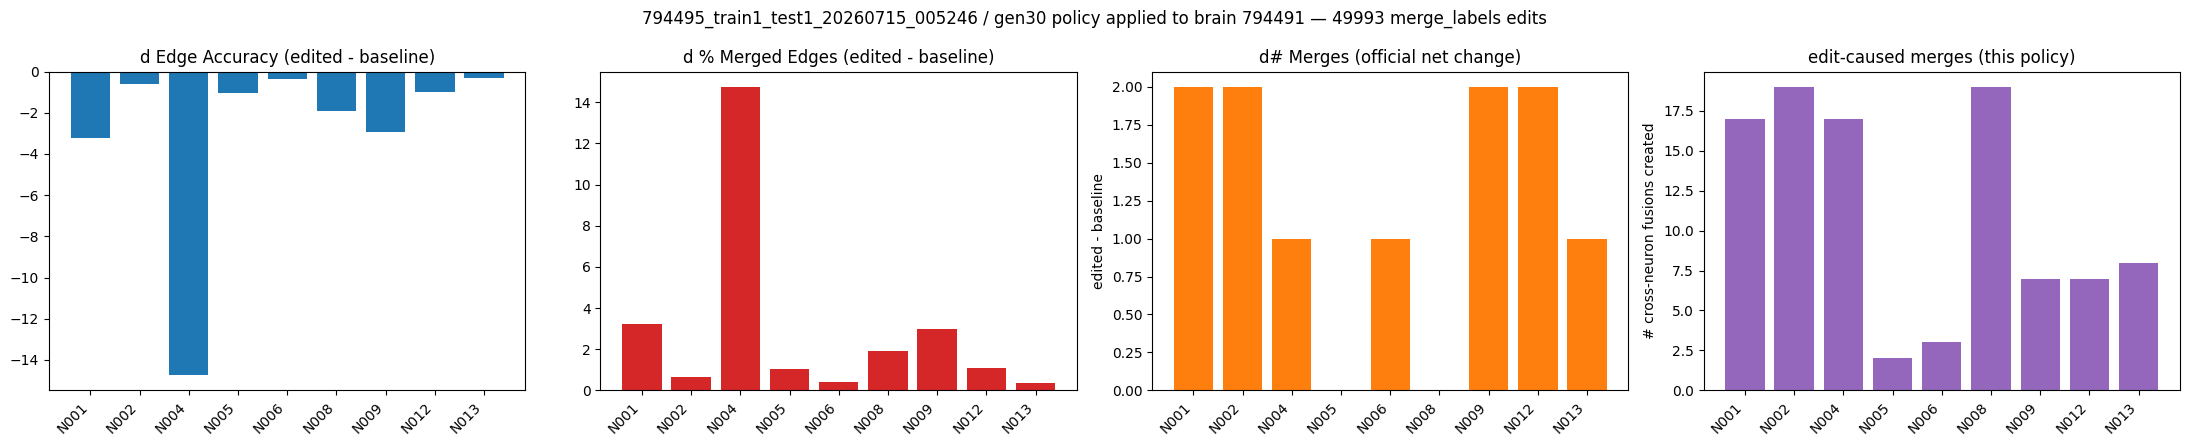

saved per-skeleton deltas -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/794495_train1_test1_20260715_005246/policy_analysis/per_skeleton_deltas_gen30_794491.csv
saved merge comparison  -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/794495_train1_test1_20260715_005246/policy_analysis/merge_comparison_gen30_794491.csv


In [7]:
# Visual summary: per-skeleton dEdgeAcc and d%MergedEdges (the merge-error component).
# Use delta.index (defined in the metric-table cell) rather than a bare `b`,
# which other cells reuse as a loop/throwaway variable.
names = list(delta.index)
x = np.arange(len(names))
_xt = [n.split('-')[0] for n in names]
# Four panels: combined-quality delta, merge-error % delta (effect), and the TWO
# merge-count views side by side so both are shown explicitly:
#   (3) d# Merges       — OFFICIAL signed net change (the reported metric);
#   (4) edit-caused merges — how many cross-neuron fusions THIS policy created
#                         (the cause d# Merges can hide when new merges cancel
#                          pre-existing ones, e.g. N013: d# Merges 0 but 26 caused).
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
axes[0].bar(x, delta.loc[names, "dEdge Accuracy"], color="#1f77b4")
axes[0].axhline(0, color="k", lw=0.6); axes[0].set_title("d Edge Accuracy (edited - baseline)")
axes[0].set_xticks(x); axes[0].set_xticklabels(_xt, rotation=45, ha="right")
axes[1].bar(x, delta.loc[names, "d% Merged Edges"], color="#d62728")
axes[1].axhline(0, color="k", lw=0.6); axes[1].set_title("d % Merged Edges (edited - baseline)")
axes[1].set_xticks(x); axes[1].set_xticklabels(_xt, rotation=45, ha="right")
axes[2].bar(x, delta.loc[names, "d# Merges"], color="#ff7f0e")
axes[2].axhline(0, color="k", lw=0.6); axes[2].set_title("d# Merges (official net change)")
axes[2].set_ylabel("edited - baseline")
axes[2].set_xticks(x); axes[2].set_xticklabels(_xt, rotation=45, ha="right")
axes[3].bar(x, comp.loc[names, "edit-caused merges"], color="#9467bd")
axes[3].set_title("edit-caused merges (this policy)")
axes[3].set_ylabel("# cross-neuron fusions created")
axes[3].set_xticks(x); axes[3].set_xticklabels(_xt, rotation=45, ha="right")
fig.suptitle(f"{RUN_NAME} / {GEN} policy applied to brain {BRAIN_ID} — {len(edits)} merge_labels edits")
fig.tight_layout(); plt.show()

# --- SAVE per-skeleton metric deltas + this figure to the run folder ---
# Reloadable artifacts under runs/<run>/policy_analysis/. The CSV is the full
# base/edit/delta table (`comp`, incl. the WEIGHTED MEAN row). Figure is shown inline,
# not saved.
_ana_dir = RUN_DIR / "policy_analysis"
_ana_dir.mkdir(parents=True, exist_ok=True)
_tag = f"{GEN}_{BRAIN_ID}"
_per_skel_csv = _ana_dir / f"per_skeleton_deltas_{_tag}.csv"
comp.round(6).to_csv(_per_skel_csv)
print(f"saved per-skeleton deltas -> {_per_skel_csv}")

# Also save a FOCUSED merge-comparison CSV: the two merge-count views side by side
# (official net change vs edit-caused), plus base/edit # Merges and d% Merged Edges
# for context. Small and self-explanatory; the full table is in the CSV above.
_merge_cols = [c for c in ["base # Merges", "edit # Merges", "d# Merges",
                           "edit-caused merges", "d% Merged Edges"] if c in comp.columns]
_merge_csv = _ana_dir / f"merge_comparison_{_tag}.csv"
comp[_merge_cols].round(4).to_csv(_merge_csv)
print(f"saved merge comparison  -> {_merge_csv}")

## 5. Pick a few repaired SplitSites to visualize

A **repaired** SplitSite = an enumerated SplitSite whose two fragment labels (a) the policy actually merged, and (b) belong to the SAME GT neuron (a real split it correctly closed). We pick `N_EXAMPLES` of them deterministically, spread evenly across the gap range (so the examples differ); each becomes one before/after panel below.

`RESTRICT_TO` (set in cell 0) limits which GT neurons the shown repairs may sit on — `None` (all 12), `"train"`, or `"heldout"` — using the run's `split.json`. It affects only **which examples are displayed**, never the scoring or the edits.

In [8]:
SEED = np.random.randint(0,10000)                                      # which repaired SplitSites to visualize (deterministic pick)
N_EXAMPLES = 10                                 # how many repaired SplitSites to visualize
RESTRICT_TO = None                             # which GT neurons the visualized repairs may sit on:
                                               #   None      -> all 12 GT skeletons (no restriction)
                                               #   "train"   -> only this run's TRAIN skeletons
                                               #   "heldout" -> only this run's HELD-OUT skeletons
                                               # (reads the run's split.json; affects ONLY which
                                               #  examples are shown, NOT scoring or the edits.)

In [9]:
def _pair_key(a, b):
    a, b = str(a), str(b); return (a, b) if a <= b else (b, a)

accepted = {_pair_key(e["label_a"], e["label_b"]) for e in edits}

def _dominant(lbl):
    c = label_gt_map.get(str(lbl)); return max(c, key=c.get) if c else None

# RESTRICT_TO -> the set of GT skeleton names a repair is allowed to sit on. Reads the
# run's split.json (the SAME train/held-out partition the evolution used). None = all.
allowed_neurons = None
if RESTRICT_TO is not None:
    split = json.loads((RUN_DIR / "split.json").read_text())
    per_brain = split["per_brain"][BRAIN_ID]
    key = {"train": "train", "heldout": "heldout"}[RESTRICT_TO]
    allowed_neurons = set(per_brain[key])
    print(f"RESTRICT_TO={RESTRICT_TO!r}: {len(allowed_neurons)} GT skeletons -> {sorted(allowed_neurons)}")
else:
    print("RESTRICT_TO=None: any of the 12 GT skeletons")

repaired = []  # SplitSites the policy merged AND that are real splits (same GT neuron)
for s in split_sites:
    la, lb = str(s.label_a), str(s.label_b)
    if _pair_key(la, lb) not in accepted:
        continue
    da, db = _dominant(la), _dominant(lb)
    if da is None or da != db:
        continue
    if allowed_neurons is not None and da not in allowed_neurons:
        continue                      # repair sits on a neuron outside the requested split
    repaired.append(s)
print(f"{len(repaired)} repaired real-split SplitSites available"
      + (f" on {RESTRICT_TO} neurons" if RESTRICT_TO else ""))
assert repaired, "no repaired SplitSites match the filter — try RESTRICT_TO=None or another GEN"

# Deterministic, spread-out pick: sort by gap and take N_EXAMPLES evenly-spaced
# samples from the middle band (skip the extreme-near/extreme-far tails). Shift by
# SEED to get a different (still reproducible) set.
repaired.sort(key=lambda s: s.gap_um)
band = repaired[len(repaired)//10 : 9*len(repaired)//10] or repaired
idxs = [int((k + 0.5) * len(band) / N_EXAMPLES) + SEED for k in range(N_EXAMPLES)]
sites_to_show = [band[i % len(band)] for i in idxs]

for k, s in enumerate(sites_to_show):
    c = tuple((np.asarray(s.xyz_a, float) + np.asarray(s.xyz_b, float)) / 2.0)
    print(f"  example {k}: {s.label_a} <-> {s.label_b}, gap {s.gap_um:.2f} um, "
          f"GT neuron {_dominant(s.label_a)}, center(um) {tuple(round(v,1) for v in c)}")

RESTRICT_TO=None: any of the 12 GT skeletons
439 repaired real-split SplitSites available
  example 0: 3258495249 <-> 3258485981, gap 3.74 um, GT neuron N001-794491-JG, center(um) (np.float64(10073.5), np.float64(21892.5), np.float64(10335.0))
  example 1: 2928084425 <-> 2820240242, gap 2.41 um, GT neuron N002-794491-PP, center(um) (np.float64(20993.1), np.float64(18369.8), np.float64(9440.8))
  example 2: 3891452922 <-> 3675773855, gap 2.58 um, GT neuron N002-794491-PP, center(um) (np.float64(12370.2), np.float64(20642.0), np.float64(12372.1))
  example 3: 3790694441 <-> 3790694269, gap 2.86 um, GT neuron N002-794491-PP, center(um) (np.float64(13266.7), np.float64(22330.2), np.float64(11975.5))
  example 4: 2403799117 <-> 2403799119, gap 3.00 um, GT neuron N013-794491-PP, center(um) (np.float64(15933.0), np.float64(20013.0), np.float64(7740.5))
  example 5: 2834236563 <-> 3056103662, gap 3.16 um, GT neuron N001-794491-JG, center(um) (np.float64(12512.0), np.float64(24402.5), np.float6

## 6. Visualize the repaired regions — MIP + GT + fragments, BEFORE vs AFTER

For each chosen SplitSite (3 in total), the same panels as `visualization_showcase.ipynb`:

1. **Raw image MIP** (XY / XZ / YZ) — the fluorescence the policy implicitly trusted at the gap.
2. **GT skeleton** (lime) — shown **once** as the truth reference.
3. **Fragments BEFORE** — coloured by raw connected component: the two fragments at the site are **different colours** (the split the segmentation made).
4. **Fragments AFTER** — coloured by the policy's edited equivalence class: the merged pair is now **one colour** (the repair).

Skeletons are proper edge MIPs (lines, not dots) via `plot_skeleton_mips`.

In [10]:
PATCH = 160                                   # receptive-field cube side (voxels) for the volume viz

In [11]:
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset
from proofreader_evolve.harness.edit_handler import EditHandler

# Same *_add.pkl cache visualization_showcase uses: agentic SkeletonGraph
# (nodes_in_patch / edges_in_patch / node_component_id / node_segment_id) + GCS reader.
#
# GUARD: the visualization cache (_add) MUST match the scoring/candidate cache
# (cell 4's `cache_path`) on min_cable_length. They are TWO separate pickles, so a
# stale or mismatched _add file would silently show fragments whose ids/components
# differ from the ones the policy actually scored/edited -> colours wrong, repairs
# missing, no error. Fail loudly here instead.
from pathlib import Path as _Path
add_cache = f"../../cache/dataset_cache_{BRAIN_ID}_mcl{MCL}_add.pkl"
assert _Path(add_cache).exists(), (
    f"visualization cache not found: {add_cache}\n"
    f"  build it (load_skeletons.ipynb with the _add extras) or fix BRAIN_ID/mcl.")
_mcl_score = int(re.search(r"_mcl(\d+)", _Path(cache_path).name).group(1))
_mcl_viz   = int(re.search(r"_mcl(\d+)", _Path(add_cache).name).group(1))
assert _mcl_viz == _mcl_score, (
    f"cache mismatch: scoring/candidate cache is mcl{_mcl_score} ({_Path(cache_path).name}) "
    f"but visualization cache is mcl{_mcl_viz} ({_Path(add_cache).name}). They must share the "
    f"same min_cable_length or the visualized fragments will not match the scored ones.")
bd = BrainDataset.load_from_cache(add_cache)
gt_viz, fr_viz = bd.gt_graph, bd.fragments_graph
# Cross-check the actual fragment universes agree (defends against a same-named but
# differently-built _add cache): the scored graph and the viz graph should cover the
# same segment ids. Warn (not fail) if they drift, since viz is non-scoring.
try:
    _seg_score = {str(fragments_graph.node_segment_id(n)) for n in fragments_graph.nodes}
    _seg_viz   = {str(fr_viz.node_segment_id(n)) for n in fr_viz.nodes}
    _missing = _seg_score - _seg_viz
    if _missing:
        print(f"[WARN] {len(_missing)} segment id(s) the policy scored are ABSENT from the "
              f"visualization cache (e.g. {sorted(_missing)[:5]}) — those repairs cannot be "
              f"drawn. Likely the two caches were built differently.")
    else:
        print(f"cache check OK: viz covers all {len(_seg_score)} scored segment ids (mcl{_mcl_score}).")
except Exception as _e:
    print(f"[WARN] could not cross-check fragment universes ({_e}); proceeding.")
aniso = gt_viz.anisotropy
handler = EditHandler(edits, all_labels=prepared.all_fragment_labels)
PATCH_SHAPE = (PATCH, PATCH, PATCH)

SHOW_SLICES = True                              # also show multi-depth raw-image slices
SLICE_FRACTIONS = (0.2, 0.4, 0.5, 0.6, 0.8)     # depth fractions for plot_slices rows


def plot_slices(patch, title="", fractions=SLICE_FRACTIONS):
    """Several single-plane SLICES at increasing depth, in ONE figure (from
    visualization_showcase.ipynb). Unlike a MIP (which maxes over the whole depth),
    each panel is one true imaging layer ``patch[int(f*depth)]``. Rows = depth
    fraction along the projection axis; columns = XY / XZ / YZ."""
    nz, ny, nx = patch.shape
    names = ["XY (vary z)", "XZ (vary y)", "YZ (vary x)"]
    sizes = [nz, ny, nx]
    vmax = np.percentile(patch, 99.9)
    nrows = len(fractions)
    fig, axs = plt.subplots(nrows, 3, figsize=(10, 3.2 * nrows))
    axs = np.atleast_2d(axs)
    for r, frac in enumerate(fractions):
        idx = [min(int(frac * s), s - 1) for s in sizes]
        planes = [patch[idx[0]], patch[:, idx[1]], patch[:, :, idx[2]]]
        for c, (ax, plane, nm) in enumerate(zip(axs[r], planes, names)):
            ax.imshow(plane, cmap="gray", vmax=vmax)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(nm, fontsize=14)
            if c == 0:
                ax.set_ylabel(f"{int(frac * 100)}% depth\n(plane {idx[0]})", fontsize=12)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_example(site):
    """Render ONE repaired SplitSite the visualization_showcase way:
       (1) raw-image MIP (XY/XZ/YZ),
       (1b) raw-image multi-depth SLICES (when SHOW_SLICES),
       (2) GT skeleton MIPs (lime) — shown ONCE, the truth reference,
       (3) fragment skeleton MIPs BEFORE the edit (coloured by raw component),
       (4) fragment skeleton MIPs AFTER  the edit (coloured by merged class).
    The two fragments the policy merged are DIFFERENT colours before and ONE colour
    after; GT is the same in both, so we draw it only once.
    """
    center_um = tuple((np.asarray(site.xyz_a, float) + np.asarray(site.xyz_b, float)) / 2.0)
    center_voxel = img_util.to_voxels(center_um, aniso)          # (z, y, x)
    offset = tuple(c - s // 2 for c, s in zip(center_voxel, PATCH_SHAPE))
    img_patch = np.squeeze(bd.img.read(center_voxel, PATCH_SHAPE))

    gt_nodes, gt_ncomp = gt_viz.nodes_in_patch(offset, PATCH_SHAPE, return_components=True)
    gt_edges, gt_ecomp = gt_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)
    fr_nodes, fr_nid, fr_ncomp = fr_viz.nodes_in_patch(
        offset, PATCH_SHAPE, return_ids=True, return_components=True)
    fr_edges, fr_ecomp = fr_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)

    # Remap fragment component-id -> the policy's edited equivalence class, so the
    # merged pair shares a colour AFTER. (BEFORE keeps the raw component id.)
    comp_rep = {}
    for nid, comp in zip(fr_nid, fr_ncomp):
        comp_rep.setdefault(int(comp), int(nid))
    comp_edited = {c: handler.get(str(fr_viz.node_segment_id(rep))) for c, rep in comp_rep.items()}
    cls_int = {cls: i for i, cls in enumerate(sorted(set(comp_edited.values())))}
    def to_after(arr):
        return np.array([cls_int[comp_edited[int(c)]] for c in arr], dtype=int)
    fr_ncomp_after, fr_ecomp_after = to_after(fr_ncomp), to_after(fr_ecomp)

    tag = (f"SplitSite {site.label_a}+{site.label_b}  gap {site.gap_um:.2f} µm  "
           f"GT {_dominant(site.label_a)}  @ {tuple(round(v,1) for v in center_um)} µm")
    print(f"\n=== {tag} ===")
    print(f"GT nodes/edges in patch: {len(gt_nodes)}/{len(gt_edges)}   "
          f"fragment nodes/edges: {len(fr_nodes)}/{len(fr_edges)}")

    print("Raw image (MIP):")
    img_util.plot_mips(img_patch)
    if SHOW_SLICES:
        print(f"Raw image (slices at {[int(f*100) for f in SLICE_FRACTIONS]}% depth):")
        plot_slices(img_patch)

    print("GT skeleton (lime) — truth reference, shown once:")
    img_util.plot_skeleton_mips({
        "GT": {"nodes": gt_nodes, "node_components": gt_ncomp,
               "edges": gt_edges, "components": gt_ecomp, "color": "lime"},
    }, PATCH_SHAPE, separate_rows=True)

    print("Fragments BEFORE — by raw connected component (the split = two colours):")
    img_util.plot_skeleton_mips({
        "Fragments (before)": {"nodes": fr_nodes, "node_components": fr_ncomp,
                               "edges": fr_edges, "components": fr_ecomp, "color": "cyan"},
    }, PATCH_SHAPE, separate_rows=True)

    print("Fragments AFTER — by policy's merged class (the repair = one colour):")
    img_util.plot_skeleton_mips({
        "Fragments (after)": {"nodes": fr_nodes, "node_components": fr_ncomp_after,
                              "edges": fr_edges, "components": fr_ecomp_after, "color": "cyan"},
    }, PATCH_SHAPE, separate_rows=True)

print("setup ready: show_example()")

cache check OK: viz covers all 678895 scored segment ids (mcl100).
setup ready: show_example()


In [12]:
from matplotlib.backends.backend_pdf import PdfPages

# Render each chosen example and save ITS figures (raw MIP, depth slices, GT,
# fragments before/after) into its OWN multi-page PDF, under a dedicated subfolder
# of this run: runs/<run>/policy_viz/. One site -> one PDF (5 pages).
#
# The showcase plotters call plt.show() internally; under the Jupyter INLINE backend
# that *closes* each figure, so we'd collect none. We temporarily replace plt.show
# with a no-op so figures persist until written, then restore it. (Figures go to the
# PDFs, not inline — open the PDFs to view.)
VIZ_DIR = RUN_DIR / "policy_viz"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

_real_show = plt.show
plt.show = lambda *a, **k: None
try:
    for k, s in enumerate(sites_to_show):
        plt.close("all")                          # isolate THIS site's figures
        show_example(s)
        figs = [plt.figure(num) for num in plt.get_fignums()]
        # One PDF per site: index + label pair + GT neuron (no seed in the name).
        name = f"ex{k:02d}_{s.label_a}-{s.label_b}_{_dominant(s.label_a)}.pdf"
        pdf_path = VIZ_DIR / name
        with PdfPages(pdf_path) as pdf:
            for f in figs:
                pdf.savefig(f, bbox_inches="tight")
        print(f"  saved {len(figs)} figures -> {pdf_path}")
finally:
    plt.show = _real_show
    plt.close("all")
print(f"\ndone: {len(sites_to_show)} per-site PDFs in {VIZ_DIR}")


=== SplitSite 3258495249+3258485981  gap 3.74 µm  GT N001-794491-JG  @ (np.float64(10073.5), np.float64(21892.5), np.float64(10335.0)) µm ===
GT nodes/edges in patch: 133/126   fragment nodes/edges: 88/80
Raw image (MIP):
Raw image (slices at [20, 40, 50, 60, 80]% depth):
GT skeleton (lime) — truth reference, shown once:
Fragments BEFORE — by raw connected component (the split = two colours):
Fragments AFTER — by policy's merged class (the repair = one colour):
  saved 5 figures -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/794495_train1_test1_20260715_005246/policy_viz/ex00_3258495249-3258485981_N001-794491-JG.pdf

=== SplitSite 2928084425+2820240242  gap 2.41 µm  GT N002-794491-PP  @ (np.float64(20993.1), np.float64(18369.8), np.float64(9440.8)) µm ===
GT nodes/edges in patch: 138/133   fragment nodes/edges: 134/128
Raw image (MIP):
Raw image (slices at [20, 40, 50, 60, 80]% depth):
GT skeleton (lime) — truth refe

## 7. (optional) Export the edits for this brain

The lightweight, auditable artifact: every `merge_labels` pair the policy proposed. (We do not materialize a repaired voxel volume — edits are a label-equivalence overlay, see `proofreader_evolve/todo.md`.)

In [13]:
# out = Path(f"./{RUN_NAME}_{GEN}_{BRAIN_ID}_edits.json")
# out.write_text(json.dumps({
#     "run": RUN_NAME, "generation": GEN, "brain": BRAIN_ID,
#     "n_edits": len(edits),
#     "split_repair": {k: repair[k] for k in ("correct", "false", "unscored")},
#     "edits": edits,
# }, indent=2))
# print("wrote", out, f"({len(edits)} edits)")

## 8. Split-error repair coverage — fixed vs remaining

How many split errors did this policy repair, and how many remain? Reported in **two
units** so it ties out against the evolution loop:

- **(A) per-edit** — every `merge_labels` edit counts (union-find means one repaired
  neuron spans many merge edges). This is the dense number the gate optimizes; its
  **held-out `correct`** reproduces `heldout_split_repair_score` in `ledger.jsonl`.
- **(B) per-site** — distinct reachable split errors (deduped by label-pair): *how
  many places* were fixed vs. left unrepaired. This is the smaller, intuitive count.

Each is split **train vs held-out** using the run's own per-split label→neuron maps
(the SAME scope the evolution used), so (A)'s held-out column matches the gate.

**Ceiling caveat:** *reachable* = within the candidate stream (the `mcl`-filtered
fragment cache). Split errors on sub-`min_cable_length` fragments are not enumerated,
so they sit outside BOTH denominators — a recall ceiling, not a miss.

In [14]:
# Split-error repair coverage, reported in BOTH units so it ties out against the
# evolution loop:
#   (A) PER-EDIT  (matches the gate's split-repair score in ledger.jsonl): every
#       merge_labels edit counts; union-find means one repaired neuron yields many
#       edges, so this is the large, dense number the gate optimizes.
#   (B) PER-SITE  (deduped by label-pair): how many DISTINCT reachable split errors
#       were closed — the smaller 'how many places did we fix' number.
# We further split each by train vs held-out, using the run's OWN per-split maps so
# (A)'s held-out column reproduces ledger 'heldout_split_repair_score'.

_split = json.loads((RUN_DIR / "split.json").read_text())
_per_brain = _split["per_brain"][BRAIN_ID]
_train_names, _heldout_names = _per_brain["train"], _per_brain["heldout"]
_train_set, _heldout_set = set(_train_names), set(_heldout_names)

# Per-split label->neuron maps (SAME scope the evolution used): a label is only
# 'dominant on a train neuron' within the train map, etc. This is what makes the
# per-edit held-out count equal the gate's number (full-brain would over-count).
_train_map   = inc.label_gt_counts(prepared, gt_names=_train_names)
_heldout_map = inc.label_gt_counts(prepared, gt_names=_heldout_names)

# ---------- (A) PER-EDIT, per-split (reproduces the gate's classify_merge_edits) ----
_rep_train   = inc.classify_merge_edits(edits, _train_map)
_rep_heldout = inc.classify_merge_edits(edits, _heldout_map)

# ---------- (B) PER-SITE, deduped reachable real splits (fixed vs remaining) --------
# candidate_split_sites already keeps ONE site per unordered label-pair, so iterating
# split_sites is per-distinct-pair. 'dominant neuron' uses the per-split maps so a
# pair is bucketed train/held-out consistently with (A).
from collections import defaultdict
def _dom_in(mp, lbl):
    c = mp.get(str(lbl)); return max(c, key=c.get) if c else None

site_stats = defaultdict(lambda: {"fixed": 0, "remaining": 0})
for s in split_sites:
    la, lb = str(s.label_a), str(s.label_b)
    # decide which split this pair's real-repair belongs to: try train then held-out
    for bucket, mp in (("train", _train_map), ("heldout", _heldout_map)):
        da, db = _dom_in(mp, la), _dom_in(mp, lb)
        if da is not None and da == db:        # reachable real split on this bucket
            key = "fixed" if _pair_key(la, lb) in accepted else "remaining"
            site_stats[bucket][key] += 1
            break   # a pair belongs to at most one neuron/bucket

# ---------- report ----------
def _pct(n, d): return f"{100.0*n/d:.1f}%" if d else "--"

print(f"Policy: {RUN_NAME} / {GEN}   brain {BRAIN_ID}   ({len(edits)} merge_labels edits, "
      f"{len(split_sites)} distinct candidate pairs)\n")

print("(A) PER-EDIT split-repair  (correct = split errors repaired; ties out to ledger)")
print(f"    {'split':<10}{'correct':>9}{'false':>7}{'unscored':>10}")
for nm, rep in (("train", _rep_train), ("held-out", _rep_heldout)):
    print(f"    {nm:<10}{rep['correct']:>9}{rep['false']:>7}{rep['unscored']:>10}")
print(f"    -> held-out correct = {_rep_heldout['correct']} "
      f"(should match ledger 'heldout_split_repair_score' for this run/gen)")

print("\n(B) PER-SITE coverage  (distinct reachable split errors: fixed vs remaining)")
hdr = f"    {'split':<10}{'reachable':>11}{'fixed':>8}{'remaining':>11}{'coverage':>10}"
print(hdr)
tot_r=tot_f=tot_x=0
for _bk in ("train", "heldout"):
    f_, x_ = site_stats[_bk]["fixed"], site_stats[_bk]["remaining"]; r_ = f_ + x_
    tot_r+=r_; tot_f+=f_; tot_x+=x_
    print(f"    {_bk:<10}{r_:>11}{f_:>8}{x_:>11}{_pct(f_,r_):>10}")
print(f"    {'ALL':<10}{tot_r:>11}{tot_f:>8}{tot_x:>11}{_pct(tot_f,tot_r):>10}")

print(f"\n=> {tot_f} of {tot_r} DISTINCT reachable split errors fixed ({_pct(tot_f,tot_r)}); "
      f"{tot_x} reachable-but-unrepaired.")
print("   (A) counts every merge edge (one repaired neuron = many edges) — the dense")
print("   number the gate optimizes; (B) counts distinct fixed places. Both EXCLUDE")
print("   split errors on sub-mcl fragments (outside the candidate stream = recall ceiling).")

# --- SAVE coverage stats to the run folder (reloadable JSON + per-site CSV) ---
_ana_dir = RUN_DIR / "policy_analysis"
_ana_dir.mkdir(parents=True, exist_ok=True)
_tag = f"{GEN}_{BRAIN_ID}"
_image_on = (ctx.get("read_image_patch") is not None)
_coverage = {
    "run": RUN_NAME, "generation": GEN, "brain": BRAIN_ID,
    "image_reader_enabled": bool(_image_on),   # False => geometry-only subset, NOT the true score
    "n_merge_labels_edits": len(edits),
    "n_distinct_candidate_pairs": len(split_sites),
    # Count-level cause behind d% Merged Edges: merge sites THIS revision introduced
    # (fused class unifies >=2 raw labels), total across all GT skeletons.
    "introduced_merge_sites_total": int(edit_caused_merges.sum()),
    "per_edit": {            # (A) ties out to ledger heldout_split_repair_score
        "train":   {k: _rep_train[k]   for k in ("correct", "false", "unscored")},
        "heldout": {k: _rep_heldout[k] for k in ("correct", "false", "unscored")},
    },
    "per_site": {            # (B) distinct reachable split errors fixed vs remaining
        _bk: dict(site_stats[_bk]) for _bk in ("train", "heldout")
    },
}
_cov_json = _ana_dir / f"split_repair_coverage_{_tag}.json"
_cov_json.write_text(json.dumps(_coverage, indent=2))

# Per-site table as a tidy CSV too (one row per bucket).
_cov_rows = []
for _bk in ("train", "heldout"):
    f_, x_ = site_stats[_bk]["fixed"], site_stats[_bk]["remaining"]; r_ = f_ + x_
    _cov_rows.append({"split": _bk, "reachable": r_, "fixed": f_, "remaining": x_,
                      "coverage_pct": (100.0*f_/r_ if r_ else float('nan')),
                      "per_edit_correct": (_rep_train if _bk=="train" else _rep_heldout)["correct"]})
_cov_csv = _ana_dir / f"split_repair_coverage_{_tag}.csv"
pd.DataFrame(_cov_rows).to_csv(_cov_csv, index=False)
if not _image_on:
    print("[WARN] image reader was OFF — saved coverage is the GEOMETRY-ONLY subset, "
          "not the policy's true score. Re-run cell 8 with the image reader for the real numbers.")
print(f"saved coverage JSON -> {_cov_json}")
print(f"saved coverage CSV  -> {_cov_csv}")

Policy: 794495_train1_test1_20260715_005246 / gen30   brain 794491   (49993 merge_labels edits, 50000 distinct candidate pairs)

(A) PER-EDIT split-repair  (correct = split errors repaired; ties out to ledger)
    split       correct  false  unscored
    train             0      0     49993
    held-out        439     19     49535
    -> held-out correct = 439 (should match ledger 'heldout_split_repair_score' for this run/gen)

(B) PER-SITE coverage  (distinct reachable split errors: fixed vs remaining)
    split       reachable   fixed  remaining  coverage
    train               0       0          0        --
    heldout           439     439          0    100.0%
    ALL               439     439          0    100.0%

=> 439 of 439 DISTINCT reachable split errors fixed (100.0%); 0 reachable-but-unrepaired.
   (A) counts every merge edge (one repaired neuron = many edges) — the dense
   number the gate optimizes; (B) counts distinct fixed places. Both EXCLUDE
   split errors on sub-mc

## 8b. Visualize the MERGE ERRORS the policy made (false merges on the TEST brain)

The precision counterpart of sections 5–6. A **false merge** = a SplitSite the policy
merged whose two fragments' dominant GT neurons **differ** (`da != db`) — a cross-neuron
fusion. Every one is rendered (no cap), and each is tagged by **BLAME**, matching the
gate's `false_policy` / `false_preexisting` split (section 8):

- **POLICY** — NEITHER fragment already spanned both neurons, so joining two clean
  single-neuron pieces is what **created** the fusion. This is the precision failure the
  gate **penalizes** (it is what subtracts from the fitness).
- **PRE-EXISTING** — at least one fragment **already** straddled both neurons (≥ 50
  nodes on each) before the merge; the two-neuron mix predates the policy, so the
  cross-neuron verdict is a GT-bookkeeping artifact, **not the policy's fault**, and is
  **not penalized**.

The blame is highlighted **in the figure** (printed heading + a coloured suptitle on
every page — red for POLICY, grey for PRE-EXISTING) **and in the PDF filename**
(`err##_POLICY_...` / `err##_PREEXISTING_...`), so the two classes are separable on disk
and at a glance. Errors are ordered POLICY-first, then by gap.

For each error, the same before/after panels as section 6:
1. **Raw image MIP + depth slices** — the fluorescence at the gap.
2. **GT skeletons** — the two neurons involved (two separate structures = the fusion is
   cross-neuron).
3. **Fragments BEFORE** — by raw component.
4. **Fragments AFTER** — the fused class (one colour = the merge).

One multi-page PDF per error under `runs/<run>/policy_viz_merge_errors/`.
**Run sections 0–6 first** — this reuses their loaded graphs, image reader, and helpers.

In [23]:
# FALSE MERGES the policy made on the TEST brain: SplitSites it MERGED whose two
# fragments belong to DIFFERENT GT neurons (da != db) — a cross-neuron fusion, i.e. a
# merge error. Precision counterpart of section 5/6's "repaired splits". Reuses the
# section-6 setup (bd, gt_viz, fr_viz, handler, aniso, PATCH_SHAPE, plot_slices,
# SHOW_SLICES, SLICE_FRACTIONS), so RUN SECTIONS 0-6 FIRST.
#
# BLAME (matches the gate + section 8's false_policy / false_preexisting split). A
# cross-neuron false merge is:
#   * PREEXISTING — at least one fragment ALREADY spanned BOTH neurons (>= 50 nodes on
#     each) before the merge; the two-neuron mix predates the policy, so the join is not
#     a NEW error and the gate does NOT penalize it.
#   * POLICY      — NEITHER fragment already spanned both neurons, so joining two clean
#     single-neuron pieces is what CREATED the fusion; this is the precision failure the
#     gate penalizes.
# We render EVERY error regardless of count, and highlight its blame in BOTH the figure
# title/suptitle AND the PDF filename (err##_POLICY_... / err##_PREEXISTING_...).
LARGE_N = 100              # advisory only: warn (do NOT truncate) beyond this many errors

# Pre-existing test = candidate.classify_merge_edits._spans_both: a fragment already
# lands on BOTH neurons with >= _MERGE_MIN_NODES (50) nodes each. label_gt_map (built in
# section 3) carries those per-neuron node counts, so we replicate the exact gate rule.
_PREEXIST_MIN = inc._MERGE_MIN_NODES
def _spans_both(label, n1, n2) -> bool:
    c = label_gt_map.get(str(label)) or {}
    return c.get(n1, 0) >= _PREEXIST_MIN and c.get(n2, 0) >= _PREEXIST_MIN
def _blame_of(la, lb, da, db) -> str:
    """'PREEXISTING' iff either fragment already straddles both neurons; else 'POLICY'."""
    return "PREEXISTING" if (_spans_both(la, da, db) or _spans_both(lb, da, db)) else "POLICY"

# Collect false-merge SplitSites: accepted AND cross-neuron. Iterating split_sites gives
# the SplitSite object (with coords for the patch centre); da/db come from the FULL-brain
# label->neuron map (same `repair` as section 8 — on an all-held-out TEST brain that
# equals the gate's held-out classification, so this reproduces the gate's `false` set).
merge_error_sites = []   # (site, da, db, blame)
for s in split_sites:
    la, lb = str(s.label_a), str(s.label_b)
    if _pair_key(la, lb) not in accepted:
        continue                       # policy did not merge this pair
    da, db = _dominant(la), _dominant(lb)
    if da is None or db is None or da == db:
        continue                       # unscored, or SAME neuron (a correct repair) -> not an error
    merge_error_sites.append((s, da, db, _blame_of(la, lb, da, db)))

# POLICY first (the actionable errors), then by gap within each blame class.
_blame_rank = {"POLICY": 0, "PREEXISTING": 1}
merge_error_sites.sort(key=lambda t: (_blame_rank[t[3]], t[0].gap_um))
_n_pol = sum(1 for *_ , bl in merge_error_sites if bl == "POLICY")
_n_pre = len(merge_error_sites) - _n_pol
print(f"{len(merge_error_sites)} FALSE-MERGE SplitSite(s) on brain {BRAIN_ID}: "
      f"{_n_pol} POLICY-caused (penalized) + {_n_pre} PRE-EXISTING (not penalized). "
      f"section-8 repair: false={repair['false']} "
      f"(policy={repair.get('false_policy')}, preexisting={repair.get('false_preexisting')}). "
      f"Rendering ALL.")
if len(merge_error_sites) > LARGE_N:
    print(f"  [note] {len(merge_error_sites)} > {LARGE_N}: renders {len(merge_error_sites)} "
          f"PDFs (each several image reads) — may be slow, but NONE are truncated.")
for k, (s, da, db, bl) in enumerate(merge_error_sites):
    c = tuple((np.asarray(s.xyz_a, float) + np.asarray(s.xyz_b, float)) / 2.0)
    print(f"  error {k}: [{bl}] {s.label_a} (neuron {da}) <-> {s.label_b} (neuron {db}), "
          f"gap {s.gap_um:.2f} um, center(um) {tuple(round(v,1) for v in c)}")


def show_merge_error(site, da, db, blame):
    """Render ONE false-merge SplitSite, framed as an ERROR and tagged with its BLAME
    (POLICY vs PREEXISTING) in every printed heading and the figure suptitle. A BOX on
    each skeleton-MIP panel marks the ACTUAL merge location (the two joined tips / the
    gap between them), so the error is easy to find in the patch:
       (1) raw-image MIP + (1b) depth slices,
       (2) GT skeletons — the TWO distinct neurons involved      [+ error box],
       (3) fragments BEFORE the edit                              [+ error box],
       (4) fragments AFTER  — the fused class (the merge)         [+ error box].
    """
    from matplotlib.patches import Rectangle

    center_um = tuple((np.asarray(site.xyz_a, float) + np.asarray(site.xyz_b, float)) / 2.0)
    center_voxel = img_util.to_voxels(center_um, aniso)          # (z, y, x)
    offset = tuple(c - s // 2 for c, s in zip(center_voxel, PATCH_SHAPE))
    img_patch = np.squeeze(bd.img.read(center_voxel, PATCH_SHAPE))

    gt_nodes, gt_ncomp = gt_viz.nodes_in_patch(offset, PATCH_SHAPE, return_components=True)
    gt_edges, gt_ecomp = gt_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)
    fr_nodes, fr_nid, fr_ncomp = fr_viz.nodes_in_patch(
        offset, PATCH_SHAPE, return_ids=True, return_components=True)
    fr_edges, fr_ecomp = fr_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)

    # Remap fragment component-id -> the policy's edited equivalence class, so the
    # merged pair shares a colour AFTER (that shared colour IS the fusion).
    comp_rep = {}
    for nid, comp in zip(fr_nid, fr_ncomp):
        comp_rep.setdefault(int(comp), int(nid))
    comp_edited = {c: handler.get(str(fr_viz.node_segment_id(rep))) for c, rep in comp_rep.items()}
    cls_int = {cls: i for i, cls in enumerate(sorted(set(comp_edited.values())))}
    def to_after(arr):
        return np.array([cls_int[comp_edited[int(c)]] for c in arr], dtype=int)
    fr_ncomp_after, fr_ecomp_after = to_after(fr_ncomp), to_after(fr_ecomp)

    # --- Error-location box, in LOCAL (z, y, x) voxels within the patch --------------
    # The two joined tips are site.node_a / site.node_b; their coords are site.xyz_a /
    # site.xyz_b (microns). Convert to voxels and subtract the patch offset so they are
    # local to the patch, then box a fixed margin around the pair (covers both tips +
    # the gap). Same (z,y,x) order plot_skeleton_mips uses.
    _pa = np.asarray(img_util.to_voxels(site.xyz_a, aniso), float) - np.asarray(offset, float)
    _pb = np.asarray(img_util.to_voxels(site.xyz_b, aniso), float) - np.asarray(offset, float)
    _lo = np.minimum(_pa, _pb)
    _hi = np.maximum(_pa, _pb)
    _BOX_MARGIN = 12.0        # voxels of padding around the tip pair (so the box is visible)
    _lo = _lo - _BOX_MARGIN
    _hi = _hi + _BOX_MARGIN

    def _box_current_skeleton_fig():
        """Draw the error box on the 3 panels of the skeleton-MIP figure just created.
        plot_skeleton_mips called plt.show() (a no-op in the PDF loop), so that figure
        is still current -> plt.gcf().axes are its XY/XZ/YZ panels, in that order."""
        plane_axes = [(1, 2), (0, 2), (0, 1)]   # (row_axis a, col_axis b) per panel
        fig = plt.gcf()
        panels = [ax for ax in fig.axes]
        for ax, (a, b) in zip(panels, plane_axes):
            x0, x1 = _lo[b], _hi[b]
            y0, y1 = _lo[a], _hi[a]
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                                   edgecolor="yellow", linewidth=1.8, linestyle="-",
                                   zorder=10))

    _why = ("POLICY-CAUSED (a NEW fusion of two clean fragments — penalized by the gate)"
            if blame == "POLICY" else
            "PRE-EXISTING (a fragment already spanned both neurons before the merge — "
            "NOT the policy's fault, NOT penalized)")
    tag = (f"[{blame}] FALSE MERGE {site.label_a}+{site.label_b}  gap {site.gap_um:.2f} µm  "
           f"neurons {da} + {db}  @ {tuple(round(v,1) for v in center_um)} µm")
    print(f"\n=== {tag} ===\n    {_why}")
    print(f"GT nodes/edges in patch: {len(gt_nodes)}/{len(gt_edges)}   "
          f"fragment nodes/edges: {len(fr_nodes)}/{len(fr_edges)}")
    print("    (yellow box on the skeleton panels = the merge location: the two joined tips + gap)")

    print("Raw image (MIP):")
    img_util.plot_mips(img_patch)
    if SHOW_SLICES:
        print(f"Raw image (slices at {[int(f*100) for f in SLICE_FRACTIONS]}% depth):")
        plot_slices(img_patch)

    print(f"[{blame}] GT skeletons — the TWO neurons ({da} / {db}) joined by this merge "
          f"(coloured by GT component; yellow box = merge site):")
    img_util.plot_skeleton_mips({
        "GT (distinct neurons)": {"nodes": gt_nodes, "node_components": gt_ncomp,
                                  "edges": gt_edges, "components": gt_ecomp, "color": "lime"},
    }, PATCH_SHAPE, separate_rows=True)
    _box_current_skeleton_fig()

    print(f"[{blame}] Fragments BEFORE — by raw component (yellow box = merge site):")
    img_util.plot_skeleton_mips({
        "Fragments (before)": {"nodes": fr_nodes, "node_components": fr_ncomp,
                               "edges": fr_edges, "components": fr_ecomp, "color": "red"},
    }, PATCH_SHAPE, separate_rows=True)
    _box_current_skeleton_fig()

    print(f"[{blame}] Fragments AFTER — fused class (the merge = one colour; yellow box = merge site):")
    img_util.plot_skeleton_mips({
        "Fragments (after = ERROR)": {"nodes": fr_nodes, "node_components": fr_ncomp_after,
                                      "edges": fr_edges, "components": fr_ecomp_after, "color": "red"},
    }, PATCH_SHAPE, separate_rows=True)
    _box_current_skeleton_fig()


# Render EVERY false merge to its own multi-page PDF under policy_viz_merge_errors/.
# The FILENAME leads with the blame class (err##_POLICY_... / err##_PREEXISTING_...) so
# the two are separable on disk; a blame suptitle is stamped on every page. Same
# plt.show()-suppression trick as section 6.
from matplotlib.backends.backend_pdf import PdfPages
if not merge_error_sites:
    print(f"\nNo false merges on brain {BRAIN_ID} for {GEN} — nothing to visualize "
          f"(the policy created no cross-neuron fusions here, i.e. perfect precision "
          f"on the GT-covered edits).")
else:
    MERR_DIR = RUN_DIR / "policy_viz_merge_errors"
    MERR_DIR.mkdir(parents=True, exist_ok=True)
    _pad = max(2, len(str(len(merge_error_sites) - 1)))
    _real_show = plt.show
    plt.show = lambda *a, **k: None
    try:
        for k, (s, da, db, bl) in enumerate(merge_error_sites):   # ALL of them, no cap
            plt.close("all")                          # isolate THIS error's figures
            show_merge_error(s, da, db, bl)
            figs = [plt.figure(num) for num in plt.get_fignums()]
            # Stamp the blame + identity on every page so the PDF is self-describing.
            _st = (f"[{bl}] false merge {s.label_a}+{s.label_b}  neurons {da}+{db}  "
                   f"gap {s.gap_um:.2f} um")
            for f in figs:
                f.suptitle(_st, fontsize=11,
                           color=("#d62728" if bl == "POLICY" else "#7f7f7f"))
            # Blame leads the filename so POLICY vs PREEXISTING errors sort together.
            name = f"err{k:0{_pad}d}_{bl}_{s.label_a}-{s.label_b}_{da}__{db}.pdf"
            pdf_path = MERR_DIR / name
            with PdfPages(pdf_path) as pdf:
                for f in figs:
                    pdf.savefig(f, bbox_inches="tight")
            print(f"  [{k + 1}/{len(merge_error_sites)}] [{bl}] saved {len(figs)} figures -> {pdf_path}")
    finally:
        plt.show = _real_show
        plt.close("all")
    print(f"\ndone: ALL {len(merge_error_sites)} merge-error PDF(s) "
          f"({_n_pol} POLICY / {_n_pre} PREEXISTING) in {MERR_DIR}")


19 FALSE-MERGE SplitSite(s) on brain 794491: 4 POLICY-caused (penalized) + 15 PRE-EXISTING (not penalized). section-8 repair: false=19 (policy=4, preexisting=15). Rendering ALL.
  error 0: [POLICY] 3258490480 (neuron N001-794491-JG) <-> 3257606430 (neuron N008-794491-SP), gap 2.95 um, center(um) (np.float64(10077.0), np.float64(21752.5), np.float64(10319.6))
  error 1: [POLICY] 3887921540 (neuron N009-794491-JG) <-> 3677537241 (neuron N012-794491-SP), gap 2.97 um, center(um) (np.float64(12811.0), np.float64(19769.3), np.float64(12285.2))
  error 2: [POLICY] 2297796700 (neuron N008-794491-SP) <-> 2296912987 (neuron N001-794491-JG), gap 3.42 um, center(um) (np.float64(20015.5), np.float64(20009.8), np.float64(7255.5))
  error 3: [POLICY] 3787144604 (neuron N004-794491-MB) <-> 3681068407 (neuron N012-794491-SP), gap 3.67 um, center(um) (np.float64(12482.4), np.float64(21416.0), np.float64(11898.6))
  error 4: [PREEXISTING] 3466208919 (neuron N008-794491-SP) <-> 3148873983 (neuron N002-794

## 8c. Diagnose the merge errors — genuine fusion vs. GT-bookkeeping artifact

You looked at the section-8b PDFs and the false merges *looked correct*. That is a real
and important observation: the gate calls a merge `false` purely by the **dominant-neuron
rule** (each fragment's most-nodes GT neuron), which can flag a visually-plausible join
for reasons that are **not** a true two-neuron fusion. This section dissects each false
merge from the GT node-count split and buckets it:

- **CLEAN cross-neuron** — both fragments sit purely on *different* neurons (≥50 nodes
  each): a genuine merge error, a real precision failure.
- **FRAGMENT PRE-MERGED** — one fragment already spans *both* neurons (≥50 nodes each):
  the two-neuron mix predates this join; "dominant" is a coin-flip, not the policy's fault.
- **AMBIGUOUS (tie-break)** — a fragment's dominant neuron wins by a thin margin (<70%
  of its nodes): the cross-neuron verdict is bookkeeping; the image can legitimately look
  like one continuous cable.
- **SUB-THRESHOLD** — cross-neuron by the dense proxy, but neither neuron clears the
  50-node `%Merged` benchmark floor: the official metric would not even count it.

Cheap — pure GT bookkeeping over `label_gt_map`, no image and no re-scoring, so it only
needs **sections 0–3**. Saves `runs/<run>/policy_analysis/merge_error_diagnosis_<gen>_<brain>.csv`.

In [20]:
# DIAGNOSE each false merge: GENUINE cross-neuron fusion, or a dominant-neuron
# TIE-BREAK / pre-existing-mix artifact (the join may actually be defensible)?
# Pure GT bookkeeping over the label->neuron node counts — needs only sections 0-3
# (split_sites, accepted, label_gt_map, _dominant, ctx). CHEAP: no image, no re-score.
#
# WHY a false merge can look correct in the image: the gate calls a merge `false` iff
# the two fragments' DOMINANT GT neuron (the one each label has the MOST nodes on)
# differ. That verdict can be (a) a real fusion of two separate neurons, or (b) a
# bookkeeping artifact — a fragment that already straddles two neurons, or a dominant
# won by a razor-thin margin. This cell shows the node-count split behind each verdict.
#
# GATE LINK: the evolution gate now penalizes ONLY policy-caused false merges (see
# incremental_scoring.classify_merge_edits -> false_policy / false_preexisting). This
# cell's "FRAGMENT PRE-MERGED" category IS the gate's false_preexisting (NOT penalized);
# every other category maps to false_policy (penalized). We import the harness's own
# threshold + classifier so the notebook can NEVER drift from what the gate actually
# does, and add a `gate_verdict` column showing each error's gate treatment.

# Use the SAME threshold the harness/gate uses (do not hardcode a second copy).
_MERGE_MIN_NODES = inc._MERGE_MIN_NODES   # benchmark %Merged floor (50 by default)

def _counts(lbl):
    """label -> {neuron: node_count} on the full brain (the SAME map the gate used)."""
    return dict(label_gt_map.get(str(lbl), {}))

def _split_of(counts):
    """(dominant, dom_count, runnerup_count, total) for a label's node counts."""
    if not counts:
        return (None, 0, 0, 0)
    srt = sorted(counts.items(), key=lambda kv: -kv[1])
    dom, dc = srt[0]
    rc = srt[1][1] if len(srt) > 1 else 0
    return (dom, dc, rc, sum(counts.values()))

def _classify_false(la, lb, da, db):
    """Fine-grained category + reason for ONE false merge, from the node-count splits.

    The harness gate makes a BINARY call (false_policy vs false_preexisting); this adds
    finer buckets for human triage. The mapping to the gate:
      FRAGMENT PRE-MERGED           -> gate false_preexisting (NOT penalized)
      CLEAN / AMBIGUOUS / SUB-THRESH -> gate false_policy      (penalized)
    """
    ca, cb = _counts(la), _counts(lb)
    _, a_dc, _, a_tot = _split_of(ca)
    _, b_dc, _, b_tot = _split_of(cb)
    a_pur = (a_dc / a_tot) if a_tot else float("nan")   # A's dominant share
    b_pur = (b_dc / b_tot) if b_tot else float("nan")   # B's dominant share
    if (ca.get(da, 0) >= _MERGE_MIN_NODES and ca.get(db, 0) >= _MERGE_MIN_NODES) or \
       (cb.get(db, 0) >= _MERGE_MIN_NODES and cb.get(da, 0) >= _MERGE_MIN_NODES):
        return ("FRAGMENT PRE-MERGED",
                "a fragment already spans BOTH neurons (>=50 nodes each) — the two-neuron "
                "mix predates this merge; the cross-neuron verdict is not this policy's fault")
    if (a_pur == a_pur and a_pur < 0.70) or (b_pur == b_pur and b_pur < 0.70):
        return ("AMBIGUOUS (tie-break)",
                "a label's dominant neuron wins by a thin margin (<70% of its nodes) — the "
                "cross-neuron verdict is bookkeeping; the image may well look correct")
    if ca.get(da, 0) >= _MERGE_MIN_NODES and cb.get(db, 0) >= _MERGE_MIN_NODES:
        return ("CLEAN cross-neuron",
                "both fragments sit purely on DIFFERENT neurons (>=50 nodes each) — a "
                "genuine merge of two separate neurons; a real precision failure")
    return ("SUB-THRESHOLD",
            "cross-neuron by the proxy, but neither neuron clears the 50-node metric "
            "threshold — the official %Merged benchmark would NOT count this")

# The AUTHORITATIVE gate verdict for each edit — computed by the harness classifier
# itself (not re-derived), so the notebook shows EXACTLY what the gate penalizes.
_gate_cls = inc.classify_merge_edits(edits, label_gt_map)
_gate_policy_pairs = {_pair_key(a, b) for (a, b, *_ ) in _gate_cls.get("false_policy_pairs", [])}
print(f"HARNESS gate on this brain: false total={_gate_cls['false']}  "
      f"policy-caused (penalized)={_gate_cls.get('false_policy', '?')}  "
      f"pre-existing (ignored)={_gate_cls.get('false_preexisting', '?')}\n")

# Re-derive the false merges independently (so this cell runs standalone after §3).
_false = []
for s in split_sites:
    la, lb = str(s.label_a), str(s.label_b)
    if _pair_key(la, lb) not in accepted:
        continue
    da, db = _dominant(la), _dominant(lb)
    if da is None or db is None or da == db:
        continue
    _false.append((s, da, db))
_false.sort(key=lambda t: t[0].gap_um)

_rows = []
for s, da, db in _false:
    la, lb = str(s.label_a), str(s.label_b)
    ca, cb = _counts(la), _counts(lb)
    _, a_dc, _, a_tot = _split_of(ca)
    _, b_dc, _, b_tot = _split_of(cb)
    try:
        geom = ctx["split_geom"](s)
    except Exception:
        geom = {}
    cat, why = _classify_false(la, lb, da, db)
    # Authoritative gate treatment (from the harness classifier above).
    gate_verdict = ("false_policy (PENALIZED)" if _pair_key(la, lb) in _gate_policy_pairs
                    else "false_preexisting (ignored)")
    _rows.append({
        "label_a": la, "label_b": lb,
        "neuron_a": da, "neuron_b": db,
        # node-count split: A on its OWN neuron vs on B's neuron (and vice versa).
        # a_on_db > 0 or a_purity < 1 means fragment A itself is mixed.
        "a_on_da": ca.get(da, 0), "a_on_db": ca.get(db, 0),
        "a_purity": round(a_dc / a_tot, 2) if a_tot else float("nan"),
        "b_on_db": cb.get(db, 0), "b_on_da": cb.get(da, 0),
        "b_purity": round(b_dc / b_tot, 2) if b_tot else float("nan"),
        # geometry the policy decided on (helps see WHY it looked like a continuation)
        "gap_um": round(getattr(s, "gap_um", float("nan")), 2),
        "mutual": getattr(s, "mutual_nearest", None),
        "colinear_cos": (round(geom["colinear_cos"], 2)
                         if geom.get("colinear_cos") is not None else None),
        "deg_b": geom.get("deg_b"),
        "rad_ratio": (round(geom["rad_ratio"], 2)
                      if geom.get("rad_ratio") is not None else None),
        "category": cat, "gate_verdict": gate_verdict, "why": why,
    })

merge_error_diag = pd.DataFrame(_rows)
print(f"{len(merge_error_diag)} false merge(s) diagnosed on brain {BRAIN_ID} / {GEN}.\n")
if len(merge_error_diag):
    print("category counts (fine-grained) + gate treatment:")
    print(merge_error_diag["category"].value_counts().to_string())
    print()
    print(merge_error_diag["gate_verdict"].value_counts().to_string())
    print("\nHow to read: a_on_da / a_on_db = fragment A's node counts on its OWN vs the "
          "OTHER neuron; purity = dominant share (1.0 = fragment sits entirely on one "
          "neuron). `gate_verdict` is what the EVOLUTION GATE now does: only "
          "`false_policy` is penalized; `false_preexisting` (a fragment already spanning "
          "both neurons) is ignored. CLEAN cross-neuron = a genuine policy merge error; "
          "TIE-BREAK / SUB-THRESHOLD are policy-caused by the gate's binary rule but are "
          "borderline (see hyperparameter note); PRE-MERGED = not the policy's fault.\n")
    pd.set_option("display.width", 250, "display.max_columns", 40, "display.max_colwidth", 80)
    display(merge_error_diag.drop(columns=["why"]))
    print("\nPer-error explanation:")
    for _, r in merge_error_diag.iterrows():
        print(f"  {r['label_a']}+{r['label_b']}  [{r['category']}] -> gate: {r['gate_verdict']}\n"
              f"     {r['why']}")

    _ana_dir = RUN_DIR / "policy_analysis"; _ana_dir.mkdir(parents=True, exist_ok=True)
    _diag_csv = _ana_dir / f"merge_error_diagnosis_{GEN}_{BRAIN_ID}.csv"
    merge_error_diag.to_csv(_diag_csv, index=False)
    print(f"\nsaved merge-error diagnosis -> {_diag_csv}")
else:
    print("No false merges to diagnose (perfect precision on the GT-covered edits).")

HARNESS gate on this brain: false total=19  policy-caused (penalized)=4  pre-existing (ignored)=15

19 false merge(s) diagnosed on brain 794491 / gen30.

category counts (fine-grained) + gate treatment:
category
FRAGMENT PRE-MERGED    15
CLEAN cross-neuron      3
SUB-THRESHOLD           1

gate_verdict
false_preexisting (ignored)    15
false_policy (PENALIZED)        4

How to read: a_on_da / a_on_db = fragment A's node counts on its OWN vs the OTHER neuron; purity = dominant share (1.0 = fragment sits entirely on one neuron). `gate_verdict` is what the EVOLUTION GATE now does: only `false_policy` is penalized; `false_preexisting` (a fragment already spanning both neurons) is ignored. CLEAN cross-neuron = a genuine policy merge error; TIE-BREAK / SUB-THRESHOLD are policy-caused by the gate's binary rule but are borderline (see hyperparameter note); PRE-MERGED = not the policy's fault.



,label_a,label_b,neuron_a,neuron_b,a_on_da,a_on_db,a_purity,b_on_db,b_on_da,b_purity,gap_um,mutual,colinear_cos,deg_b,rad_ratio,category,gate_verdict
0,3466208919,3148873983,N008-794491-SP,N002-794491-PP,836,0,1.00,5614,1821,0.76,2.16,True,-0.31,2,3.57,FRAGMENT PRE-MERGED,false_preexisting (ignored)
1,3461794036,3462673128,N002-794491-PP,N009-794491-JG,1071,178,0.86,391,0,1.00,2.24,True,0.53,1,1.06,FRAGMENT PRE-MERGED,false_preexisting (ignored)
2,3041029852,3146208096,N008-794491-SP,N009-794491-JG,1439,75,0.95,165,146,0.53,2.35,True,0.28,2,1.21,FRAGMENT PRE-MERGED,false_preexisting (ignored)
3,3259370201,3150637192,N008-794491-SP,N001-794491-JG,329,119,0.73,2136,0,1.00,2.45,True,0.43,1,1.50,FRAGMENT PRE-MERGED,false_preexisting (ignored)
4,2826271353,2721963379,N002-794491-PP,N008-794491-SP,457,0,1.00,4973,408,0.92,2.81,True,0.19,2,1.82,FRAGMENT PRE-MERGED,false_preexisting (ignored)
5,3465334384,3465334382,N008-794491-SP,N002-794491-PP,467,0,1.00,451,123,0.79,2.83,True,-0.00,1,1.03,FRAGMENT PRE-MERGED,false_preexisting (ignored)
6,3890578200,3675783035,N004-794491-MB,N002-794491-PP,387,0,1.00,9021,3907,0.70,2.90,True,0.48,2,3.12,FRAGMENT PRE-MERGED,false_preexisting (ignored)
7,3258490480,3257606430,N001-794491-JG,N008-794491-SP,300,0,1.00,664,0,1.00,2.95,True,0.23,2,1.69,CLEAN cross-neuron,false_policy (PENALIZED)
8,3887921540,3677537241,N009-794491-JG,N012-794491-SP,134,0,1.00,5793,0,1.00,2.97,True,0.16,2,2.82,CLEAN cross-neuron,false_policy (PENALIZED)
9,3993993059,3993997651,N012-794491-SP,N009-794491-JG,452,323,0.58,138,0,1.00,3.00,True,0.71,1,1.34,FRAGMENT PRE-MERGED,false_preexisting (ignored)



Per-error explanation:
  3466208919+3148873983  [FRAGMENT PRE-MERGED] -> gate: false_preexisting (ignored)
     a fragment already spans BOTH neurons (>=50 nodes each) — the two-neuron mix predates this merge; the cross-neuron verdict is not this policy's fault
  3461794036+3462673128  [FRAGMENT PRE-MERGED] -> gate: false_preexisting (ignored)
     a fragment already spans BOTH neurons (>=50 nodes each) — the two-neuron mix predates this merge; the cross-neuron verdict is not this policy's fault
  3041029852+3146208096  [FRAGMENT PRE-MERGED] -> gate: false_preexisting (ignored)
     a fragment already spans BOTH neurons (>=50 nodes each) — the two-neuron mix predates this merge; the cross-neuron verdict is not this policy's fault
  3259370201+3150637192  [FRAGMENT PRE-MERGED] -> gate: false_preexisting (ignored)
     a fragment already spans BOTH neurons (>=50 nodes each) — the two-neuron mix predates this merge; the cross-neuron verdict is not this policy's fault
  2826271353+2721963

## 8e. Validate the `false_preexisting` classifier (threshold sweep + benchmark cross-check)

The gate now *excuses* pre-existing false merges — so it matters whether that
classification is correct. This section stress-tests it two independent ways, both cheap
(pure GT bookkeeping, no image, no re-scoring; needs only sections 0–3):

1. **Threshold sweep** — the `_spans_both` rule fires at **≥50 nodes on each neuron**.
   We re-run the *actual* harness classifier (`classify_merge_edits(..., preexisting_min_nodes=T)`)
   across T ∈ {10…100} and watch the policy-caused count. Stable across T ⇒ the verdicts
   are robust; flipping around T=50 ⇒ the cutoff is fragile and needs justifying.

2. **Benchmark cross-check** — does a **second, independent** detector agree that each
   "pre-existing" fragment was *already* a two-neuron merge at baseline? `collect_merge_labels`
   is the benchmark's own merge detector (the one behind `% Merged Edges`). If a
   fragment flagged `false_preexisting` is also in the benchmark's baseline merge set,
   two methods corroborate the "already merged" claim. Note the operator subtlety
   (`>50` strict vs `≥50` inclusive) can cause boundary-only disagreements at exactly 50
   nodes — the cell flags any uncorroborated rows so you can inspect them.

Saves `preexisting_threshold_sweep_<gen>_<brain>.csv` and `preexisting_benchmark_xcheck_<gen>_<brain>.csv`.

In [21]:
# VALIDATE the false_preexisting classifier two independent ways. Cheap: pure GT
# bookkeeping over `edits` + `label_gt_map` + `prepared` (already loaded); no image,
# no re-scoring. Needs sections 0-3.
#
# (1) THRESHOLD SWEEP — how sensitive is the policy/pre-existing split to the 50-node
#     cutoff? _spans_both fires at >= preexisting_min_nodes on EACH neuron. If the
#     policy-caused count barely moves across a range of thresholds, the verdicts are
#     robust; if edits flip policy<->preexisting right around 50, the cutoff is fragile.
#     We call the ACTUAL harness classifier at each threshold (not a re-implementation).
#
# (2) BENCHMARK CROSS-CHECK — does a SECOND, independent detector agree that each
#     "pre-existing" fragment was already a two-neuron merge at BASELINE (no edits)?
#     collect_merge_labels is the benchmark's own merge detector (drives % Merged
#     Edges). If a fragment flagged false_preexisting is ALSO in the benchmark's
#     baseline merge set, two methods corroborate the "already merged" claim. NOTE an
#     operator subtlety: collect_merge_labels uses `> min_nodes` (STRICT) while
#     _spans_both uses `>= preexisting_min_nodes` (INCLUSIVE) — they can disagree at
#     EXACTLY 50 nodes. We report agreement and flag any boundary-only mismatches.

# ---------- (1) threshold sweep ----------
_SWEEP = [10, 25, 40, 49, 50, 51, 60, 75, 100]
print("(1) THRESHOLD SWEEP — classify_merge_edits(preexisting_min_nodes=T) on held-out edits")
print(f"    {'T':>4} {'false_total':>12} {'policy(penalized)':>18} {'preexisting':>12}")
_sweep_rows = []
for _T in _SWEEP:
    _c = inc.classify_merge_edits(edits, label_gt_map, preexisting_min_nodes=_T)
    _sweep_rows.append({"threshold": _T, "false_total": _c["false"],
                        "false_policy": _c.get("false_policy", _c["false"]),
                        "false_preexisting": _c.get("false_preexisting", 0)})
    _mark = "  <- gate default" if _T == inc._MERGE_MIN_NODES else ""
    print(f"    {_T:>4} {_c['false']:>12} {_c.get('false_policy','?'):>18} "
          f"{_c.get('false_preexisting','?'):>12}{_mark}")
sweep_df = pd.DataFrame(_sweep_rows)
_pol_range = sweep_df["false_policy"].max() - sweep_df["false_policy"].min()
print(f"\n    policy-caused count ranges over {sweep_df['false_policy'].min()}"
      f"..{sweep_df['false_policy'].max()} across T in [{_SWEEP[0]},{_SWEEP[-1]}] "
      f"(spread={_pol_range}). "
      + ("STABLE — verdicts are robust to the threshold."
         if _pol_range <= 1 else
         "FRAGILE — verdicts move with the threshold; the 50-node cutoff needs "
         "justifying (inspect the edits that flip around T=50)."))

# ---------- (2) benchmark cross-check ----------
# The benchmark's own merge detector at BASELINE: raw labels it says already span >=2
# GT neurons (each with > min_nodes). Uses the same 50 default -> STRICT > (its rule).
_bench = inc.collect_merge_labels(prepared, min_nodes=inc._MERGE_MIN_NODES)
_bench_merged_labels = set(_bench.keys())   # raw labels the benchmark calls pre-merged
print(f"\n(2) BENCHMARK CROSS-CHECK — {len(_bench_merged_labels)} raw labels are "
      f"pre-merged per collect_merge_labels (baseline, >{inc._MERGE_MIN_NODES} nodes "
      f"on >=2 neurons).")

# For each held-out false_preexisting edit, is EITHER of its fragments in the
# benchmark's baseline merge set? (That fragment is the one _spans_both flagged.)
_pre_pairs = _gate_cls.get("false_preexisting_pairs", [])  # from cell 8c's _gate_cls
if not _pre_pairs:
    _pre_pairs = inc.classify_merge_edits(edits, label_gt_map).get("false_preexisting_pairs", [])
_xcheck = []
for (a, b, da, db) in _pre_pairs:
    a_in = str(a) in _bench_merged_labels
    b_in = str(b) in _bench_merged_labels
    _xcheck.append({"label_a": a, "label_b": b, "neuron_a": da, "neuron_b": db,
                    "a_in_benchmark_merge": a_in, "b_in_benchmark_merge": b_in,
                    "corroborated": a_in or b_in})
xcheck_df = pd.DataFrame(_xcheck)
if len(xcheck_df):
    _agree = int(xcheck_df["corroborated"].sum())
    print(f"    of {len(xcheck_df)} false_preexisting edits, {_agree} are CORROBORATED "
          f"by the benchmark detector ({_agree/len(xcheck_df):.0%}).")
    if _agree < len(xcheck_df):
        print("    [CHECK] some pre-existing verdicts are NOT confirmed by the benchmark "
              "— likely the >=50 (inclusive) vs >50 (strict) boundary, or a dominant-"
              "neuron vs >50-on-2 disagreement. Inspect the uncorroborated rows:")
    pd.set_option("display.width", 220, "display.max_columns", 20)
    display(xcheck_df)
else:
    print("    no false_preexisting edits on this brain — nothing to cross-check.")

# Save both artifacts for post-analysis.
_ana_dir = RUN_DIR / "policy_analysis"; _ana_dir.mkdir(parents=True, exist_ok=True)
sweep_df.to_csv(_ana_dir / f"preexisting_threshold_sweep_{GEN}_{BRAIN_ID}.csv", index=False)
if len(xcheck_df):
    xcheck_df.to_csv(_ana_dir / f"preexisting_benchmark_xcheck_{GEN}_{BRAIN_ID}.csv", index=False)
print(f"\nsaved sweep + cross-check -> {_ana_dir}")

(1) THRESHOLD SWEEP — classify_merge_edits(preexisting_min_nodes=T) on held-out edits
       T  false_total  policy(penalized)  preexisting
      10           19                  3           16
      25           19                  4           15
      40           19                  4           15
      49           19                  4           15
      50           19                  4           15  <- gate default
      51           19                  4           15
      60           19                  4           15
      75           19                  4           15
     100           19                  4           15

    policy-caused count ranges over 3..4 across T in [10,100] (spread=1). STABLE — verdicts are robust to the threshold.

(2) BENCHMARK CROSS-CHECK — 84 raw labels are pre-merged per collect_merge_labels (baseline, >50 nodes on >=2 neurons).
    of 15 false_preexisting edits, 15 are CORROBORATED by the benchmark detector (100%).


,label_a,label_b,neuron_a,neuron_b,a_in_benchmark_merge,b_in_benchmark_merge,corroborated
0,3466208919,3148873983,N008-794491-SP,N002-794491-PP,False,True,True
1,3461794036,3462673128,N002-794491-PP,N009-794491-JG,True,False,True
2,3041029852,3146208096,N008-794491-SP,N009-794491-JG,True,True,True
3,3259370201,3150637192,N008-794491-SP,N001-794491-JG,True,False,True
4,2826271353,2721963379,N002-794491-PP,N008-794491-SP,False,True,True
5,3465334384,3465334382,N008-794491-SP,N002-794491-PP,False,True,True
6,3890578200,3675783035,N004-794491-MB,N002-794491-PP,False,True,True
7,3993993059,3993997651,N012-794491-SP,N009-794491-JG,True,False,True
8,2714168607,2500239172,N008-794491-SP,N001-794491-JG,False,True,True
9,3675773855,3679295971,N002-794491-PP,N012-794491-SP,True,False,True



saved sweep + cross-check -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/794495_train1_test1_20260715_005246/policy_analysis


## 9. Reload saved analysis (no re-scoring)

Sections 4 and 8 write reloadable artifacts to `runs/<run>/policy_analysis/`:
`per_skeleton_deltas_<gen>_<brain>.csv` (+ `.png`) and `split_repair_coverage_<gen>_<brain>.{json,csv}`. The cell below reads them back so a later session can inspect the results without re-running the policy or the scorer.

In [22]:
# Reload the saved analysis artifacts for this run/gen (set RUN_NAME/GEN/BRAIN_ID in
# cell 0 first; no scoring needed).
_ana_dir = RUN_DIR / "policy_analysis"
_tag = f"{GEN}_{BRAIN_ID}"
_per_skel_csv = _ana_dir / f"per_skeleton_deltas_{_tag}.csv"
_cov_json     = _ana_dir / f"split_repair_coverage_{_tag}.json"

if _per_skel_csv.exists():
    per_skeleton_loaded = pd.read_csv(_per_skel_csv, index_col=0)
    print(f"per-skeleton deltas: {_per_skel_csv}")
    display(per_skeleton_loaded)
else:
    print(f"[missing] {_per_skel_csv} — run section 4 first.")

if _cov_json.exists():
    coverage_loaded = json.loads(_cov_json.read_text())
    print(f"\nsplit-repair coverage: {_cov_json}")
    if not coverage_loaded.get("image_reader_enabled", True):
        print("[WARN] this file was saved with the image reader OFF (geometry-only subset).")
    print(json.dumps(coverage_loaded, indent=2))
else:
    print(f"[missing] {_cov_json} — run section 8 first.")

per-skeleton deltas: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/794495_train1_test1_20260715_005246/policy_analysis/per_skeleton_deltas_gen30_794491.csv


,base Edge Accuracy,base % Merged Edges,base # Merges,base % Split Edges,base # Splits,base % Omit Edges,edit Edge Accuracy,edit % Merged Edges,edit # Merges,edit % Split Edges,edit # Splits,edit % Omit Edges,dEdge Accuracy,d% Merged Edges,d# Merges,d% Split Edges,d# Splits,d% Omit Edges,edit-caused merges
N001-794491-JG,68.940000,29.948633,18.000000,0.422543,801.00000,0.688664,65.710000,33.189390,20.000000,0.414418,780.000000,0.687794,-3.230000,3.240757,2.000000,-0.008126,-21.000000,-0.000871,17.0
N002-794491-PP,72.550000,25.029013,29.000000,0.677302,1070.00000,1.739478,71.960000,25.664024,31.000000,0.662221,1037.000000,1.715546,-0.590000,0.635011,2.000000,-0.015080,-33.000000,-0.023932,19.0
N004-794491-MB,69.380000,27.684275,22.000000,0.562530,628.00000,2.373443,54.640000,42.439956,23.000000,0.549389,611.000000,2.367378,-14.740000,14.755681,1.000000,-0.013141,-17.000000,-0.006065,17.0
N005-794491-HP,46.660000,52.368376,3.000000,0.330240,398.00000,0.637331,45.630000,53.427602,3.000000,0.317012,383.000000,0.629299,-1.030000,1.059226,0.000000,-0.013229,-15.000000,-0.008032,2.0
N006-794491-SP,96.130000,3.340972,3.000000,0.312775,471.00000,0.218653,95.750000,3.733026,4.000000,0.302639,456.000000,0.212137,-0.380000,0.392055,1.000000,-0.010136,-15.000000,-0.006516,3.0
N008-794491-SP,68.490000,27.630351,33.000000,0.911500,1617.00000,2.965037,66.590000,29.547633,33.000000,0.895212,1579.000000,2.963471,-1.900000,1.917282,0.000000,-0.016288,-38.000000,-0.001566,19.0
N009-794491-JG,80.880000,10.129852,11.000000,1.467682,1541.00000,7.525831,77.930000,13.112474,13.000000,1.448349,1513.000000,7.508109,-2.950000,2.982622,2.000000,-0.019333,-28.000000,-0.017722,7.0
N012-794491-SP,82.230000,14.536035,16.000000,0.867940,1738.00000,2.364003,81.220000,15.609871,18.000000,0.833782,1670.000000,2.339097,-1.010000,1.073835,2.000000,-0.034158,-68.000000,-0.024907,7.0
N013-794491-PP,81.310000,7.487967,14.000000,1.754518,3104.00000,9.443310,81.010000,7.864665,15.000000,1.724454,3032.000000,9.398215,-0.300000,0.376698,1.000000,-0.030064,-72.000000,-0.045096,8.0
WEIGHTED MEAN,75.013574,21.101788,17.333251,0.823629,1354.76327,3.059428,72.620533,23.531046,18.614618,0.804836,1317.002569,3.043412,-2.393041,2.429258,1.281368,-0.018793,-37.760701,-0.016016,99.0



split-repair coverage: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/794495_train1_test1_20260715_005246/policy_analysis/split_repair_coverage_gen30_794491.json
{
  "run": "794495_train1_test1_20260715_005246",
  "generation": "gen30",
  "brain": "794491",
  "image_reader_enabled": true,
  "n_merge_labels_edits": 49993,
  "n_distinct_candidate_pairs": 50000,
  "introduced_merge_sites_total": 99,
  "per_edit": {
    "train": {
      "correct": 0,
      "false": 0,
      "unscored": 49993
    },
    "heldout": {
      "correct": 439,
      "false": 19,
      "unscored": 49535
    }
  },
  "per_site": {
    "train": {
      "fixed": 0,
      "remaining": 0
    },
    "heldout": {
      "fixed": 439,
      "remaining": 0
    }
  }
}


## 10. TRAIN brain — repaired splits AND merge errors

Sections 1-8b cover the **TEST** (held-out) brain in full (metric table, coverage, error
diagnosis, classifier validation, plus repaired-split + merge-error PDFs). To get the
same picture for the **TRAIN** brain — and avoid re-rendering the test brain — this
section applies the SAME policy to the **train** brain only, using the shared
`plotting/policy_viz.py` helpers (no duplicated rendering code):

- **Repaired splits** — SplitSites the policy correctly merged (same GT neuron), before/
  after → `runs/<run>/<train_brain>_train/policy_viz_repairs/`.
- **Merge errors** — false merges (cross-neuron), tagged POLICY vs PRE-EXISTING in the
  title + filename, with a yellow box on the skeleton panels marking the merge location
  → `runs/<run>/<train_brain>_train/policy_viz_merge_errors/`.

Together with sections 1-8b you get BOTH brains, each rendered exactly once, in separate
per-brain subfolders. Why look at TRAIN: the reviser SAW it during evolution, so its
train-brain errors are what the failure report showed it — comparing train vs test
errors shows whether a failure mode generalizes or is test-specific. (For a legacy
per-brain-split run — one brain in both roles — this section no-ops, since sections 1-8b
already covered that brain.)

**Run section 0 first** (for RUN_DIR / GEN / MAX_CLASS_SIZE / the harness imports).
Self-contained otherwise — it re-loads the train brain's graphs and re-runs the policy.

In [ ]:
# BOTH-BRAINS visualization via the shared policy_viz module (no duplicated rendering).
# Builds a policy_viz.BrainViz per brain (loads graphs, runs the policy, scores the
# label->neuron map, loads the *_add viz cache), then renders repairs + merge errors.
import importlib
from proofreader_evolve.plotting import policy_viz as pviz
importlib.reload(pviz)   # pick up edits without restarting the kernel
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset
from proofreader_evolve.harness.edit_handler import EditHandler, normalize_edits

# --- knobs (independent of the single-brain sections above) ----------------------
N_REPAIRS_PER_BRAIN = 10       # repaired-split examples per brain (spread by gap)
REPAIR_SEED = 0                # deterministic repaired-split pick (change to resample)
PATCH_VOX = 160                # receptive-field cube side (voxels)
WITH_IMAGE = True              # build the GCS image reader (matches evolution); False = geometry-only

_split_cfg = json.loads((RUN_DIR / "split.json").read_text())
_MCL = int(_split_cfg.get("mcl", 100))
_PATCH_SHAPE = (PATCH_VOX, PATCH_VOX, PATCH_VOX)
_PREEXIST_MIN = inc._MERGE_MIN_NODES

# Which brains to render HERE. Sections 1-8b already render the TEST brain in full
# (metric table, coverage, error diagnosis, validation + repairs + merge errors), so to
# AVOID PLOTTING THE TEST BRAIN TWICE this section covers only the brain those sections
# DON'T: the TRAIN brain. Cross-brain runs have a distinct train brain -> render it.
# A legacy per-brain-split run has a single brain that sections 1-8b already cover, so
# there is nothing new to add and this section no-ops.
if _split_cfg.get("cross_brain"):
    _brain_roles = [(str(_split_cfg["train_brains"][0]), "train")]
else:
    _brain_roles = []   # single-brain run: TEST brain already done in sections 1-8b
if not _brain_roles:
    print("Nothing to add: this run has a single brain, already covered by sections 1-8b.")
print(f"Brains to visualize here (TRAIN only; TEST is sections 1-8b): {_brain_roles}")

import sys as _sys
_sys.path.insert(0, str(PROJ / "scripts"))

def _build_image_reader(brain_id, fragments_graph):
    if not WITH_IMAGE:
        return None
    try:
        from proofreader_evolve.harness.image_features import LazyImagePatchReader
        from dataset_config import get_img_path
        _prefixes = str(PROJ / "configs" / "exaspim_image_prefixes.json")
        return LazyImagePatchReader(get_img_path(brain_id, prefixes_path=_prefixes),
                                    fragments_graph)
    except Exception as _e:
        print(f"  [WARN] image reader for {brain_id} failed ({_e}); geometry-only.")
        return None

def build_brain_viz(brain_id, role):
    """Load a brain, run the final policy on it, and return a policy_viz.BrainViz."""
    print(f"\n=== building BrainViz for {brain_id} [{role}] ===")
    # prepared state (shared cache, validated; fall back to bare per-run pickle)
    _prep_path = Path(inc.shared_prepared_cache_path(brain_id))
    if not _prep_path.exists():
        _prep_path = RUN_DIR / f"prepared_{brain_id}.pkl"
    try:
        _prep = inc.PreparedBrain.load_shared(str(_prep_path), expect_brain=brain_id)
    except Exception:
        _prep = inc.PreparedBrain.load(str(_prep_path))
    # candidate fragment graph (SAME mcl the run enumerated over)
    _cache = ds.default_cache_path(brain_id, min_cable_length=_MCL)
    _frag, _gt, _pl = ds.load_cached_graphs(_cache)
    # run the policy on this brain (mirror candidate.run_candidate's ctx)
    _pe, _mod = cand._load_policy(str(POLICY))
    _raw = getattr(_mod, "ENUM_PARAMS", None)
    _raw = {**_raw} if isinstance(_raw, dict) else {}
    _raw.setdefault("max_gap_um", 15.0)
    _enum = ds.resolve_enum_params(_raw)
    _ssites, _msites, _ = cand._enumerate_sites_cached(_frag, _enum, enumerate_merges=False)
    _img = _build_image_reader(brain_id, _frag)
    _ctx = {"max_gap_um": _enum["max_gap_um"], "enum_params": dict(_enum),
            "fragments_graph": _frag, "n_split_sites": len(_ssites), "n_merge_sites": 0,
            "node_radius": getattr(_frag, "node_radius", None),
            "split_geom": (lambda s: cand._split_site_geom(_frag, s)),
            "nodes_within": (lambda xyz, r: cand._nodes_within(_frag, xyz, r)),
            "foreign_labels_near": (lambda xyz, r, exclude=(): cand._foreign_labels_near(_frag, xyz, r, exclude)),
            "read_image_patch": _img, "image_patch_shape": (16, 16, 16)}
    # Pass split + merge sites (identical to section 2's `sites = split+merge`). Both
    # enumerate with enumerate_merges=False so _msites is empty on these splits-only
    # runs, but concatenating keeps this call STRUCTURALLY identical to the test path.
    _edits = [e for e in normalize_edits(_pe(list(_ssites) + list(_msites), _ctx))
              if e.get("kind") == "merge_labels"]
    _map = inc.label_gt_counts(_prep, gt_names=None)
    print(f"  {len(_ssites)} SplitSites -> {len(_edits)} merge_labels edits"
          + ("" if _img is not None else "  [GEOMETRY-ONLY]"))
    # visualization cache (*_add) — must match mcl
    _add = f"../../cache/dataset_cache_{brain_id}_mcl{_MCL}_add.pkl"
    assert Path(_add).exists(), f"viz cache not found: {_add} (build it or fix mcl)"
    _bd = BrainDataset.load_from_cache(_add)
    _handler = EditHandler(_edits, all_labels=_prep.all_fragment_labels)
    return pviz.BrainViz(role=role, brain_id=str(brain_id), split_sites=list(_ssites),
                         edits=_edits, label_gt_map=_map, bd=_bd,
                         gt_viz=_bd.gt_graph, fr_viz=_bd.fragments_graph,
                         handler=_handler, aniso=_bd.gt_graph.anisotropy,
                         patch_shape=_PATCH_SHAPE, preexist_min=_PREEXIST_MIN)

for _brain_id, _role in _brain_roles:
    bv = build_brain_viz(_brain_id, _role)
    _sub = RUN_DIR / f"{_brain_id}_{_role}"
    # (a) repaired splits
    _reps = pviz.pick_spread(bv.repaired_sites(), N_REPAIRS_PER_BRAIN, REPAIR_SEED)
    print(f"[{_role} {_brain_id}] rendering {len(_reps)} repaired-split example(s)...")
    if _reps:
        pviz.render_repairs(bv, _reps, _sub / "policy_viz_repairs", img_util)
    # (b) merge errors — ALL of them, blame-tagged + boxed
    _errs = bv.merge_error_sites()
    _npol = sum(1 for *_ , _bl in _errs if _bl == "POLICY")
    print(f"[{_role} {_brain_id}] rendering ALL {len(_errs)} merge error(s) "
          f"({_npol} POLICY / {len(_errs) - _npol} PREEXISTING)...")
    if _errs:
        pviz.render_merge_errors(bv, _errs, _sub / "policy_viz_merge_errors", img_util)
    else:
        print(f"  no false merges on {_brain_id} [{_role}] — perfect precision on GT-covered edits.")
print("\ndone: both-brains repairs + merge errors under runs/<run>/<brain>_<role>/")